# BTSP on a linear track

**Objective:** Compare hyperparameters and evaluate spatial features pyramidal neurons learn to encode.

* Linear track (periodic)
* Agent navigates in a specific direction (and eventually back and forth)
* Target object located partway along the track.
* Two-compartment pyramidal neuron layer:
  * Somatic input: uniformly distributed Gaussian place cells (plastic)
  * Dendritic input: Target object-encoding cell (fixed)
  * Filtered dendritic self-inhibition
  * 1 pyramidal neuron only
* Learning:
  * BTSP learning: strong learning with a broad kernel, occurring when a neuron's activation passes a predetermined threshold.

In [1]:
import copy
import importlib
from pathlib import Path
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from ratinabox import utils as rutils
from tqdm import tqdm

from predhpc import agent, env, plot_fcts, run_manager
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import ext_util, hyper_util, plot_util, params_util, animate_util, gen_util, learn_util

%load_ext autoreload

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = str(Path("figures", "linear_track"))

ALL_FIGURES = dict()

In [3]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
%autoreload 2

## Hyperparameters and functions

In [5]:
NUM_STEPS = 3800
USE_HEBBIAN = False

target_position = params_util.REL_TARGET_POS * params_util.SCALE_LINEAR

agent_params = params_util.get_agent_params(
    environment="linear",
    target_position=target_position,
    wait_at_end=int(15 / params_util.DT),
)

Pyr_params = params_util.get_Pyr_params(
    environment="linear",
    log_BTSP=True,
)

## 1. Initial direction

 16%|██████▎                                | 615/3800 [00:00<00:04, 758.57it/s]

BTSP event recorded for neuron 0 at step 504 (15.12 sec).


 34%|█████████████                         | 1304/3800 [00:01<00:03, 714.66it/s]

BTSP update applied to neuron 0 at step 1198 (35.94 sec).


100%|██████████████████████████████████████| 3800/3800 [00:05<00:00, 716.37it/s]


Finishing last trajectory.


916it [00:01, 677.67it/s]


Only reached target 4 times (target: 10).
Trajectory lengths (5) to date: 28.30 +/- 15.15 sec each
Trajectory lengths (5) to date: 943.40 +/- 504.94 steps each
1 BTSP events triggered (allowed from steps 0 to 4716): occurred at step 504.


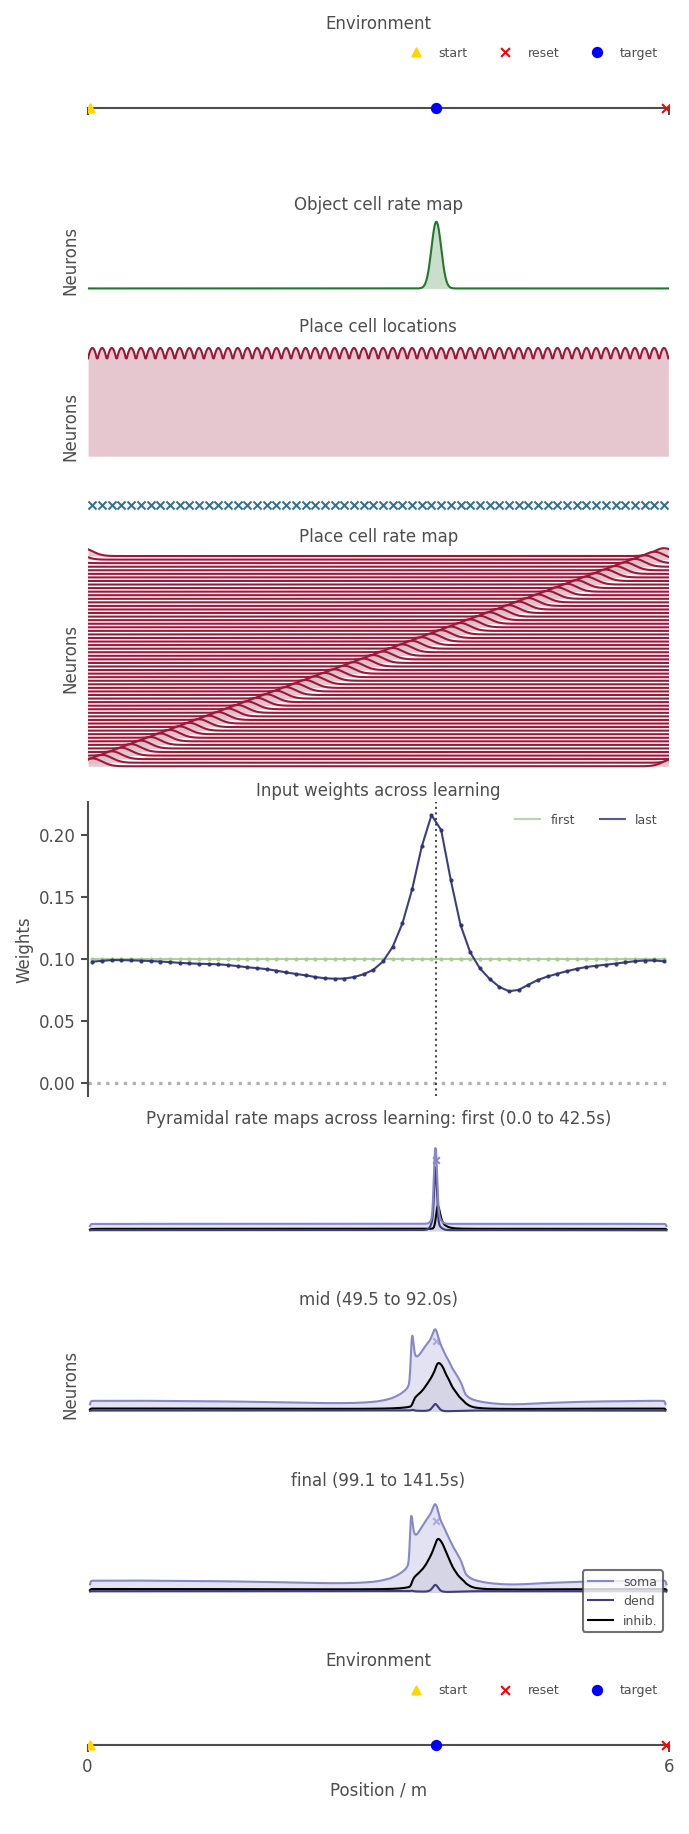

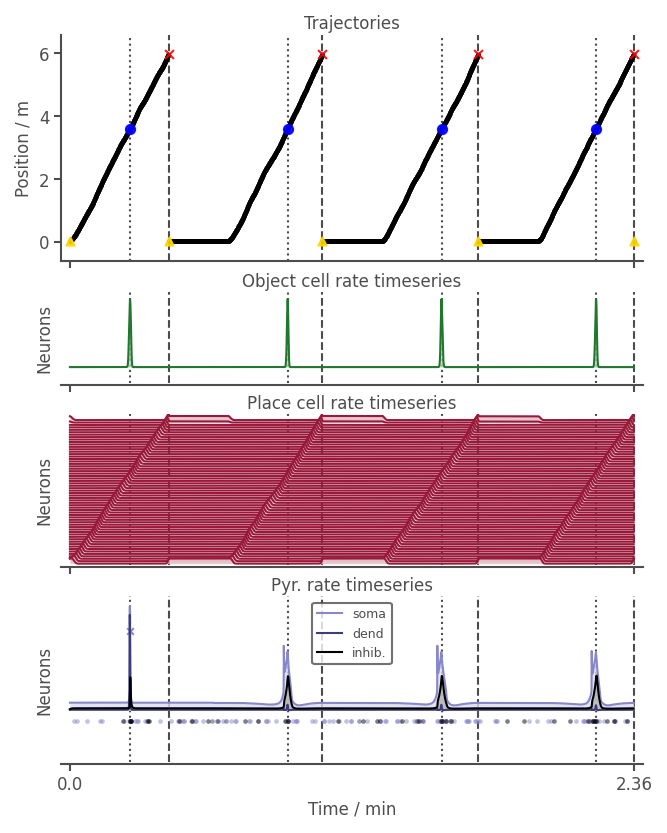

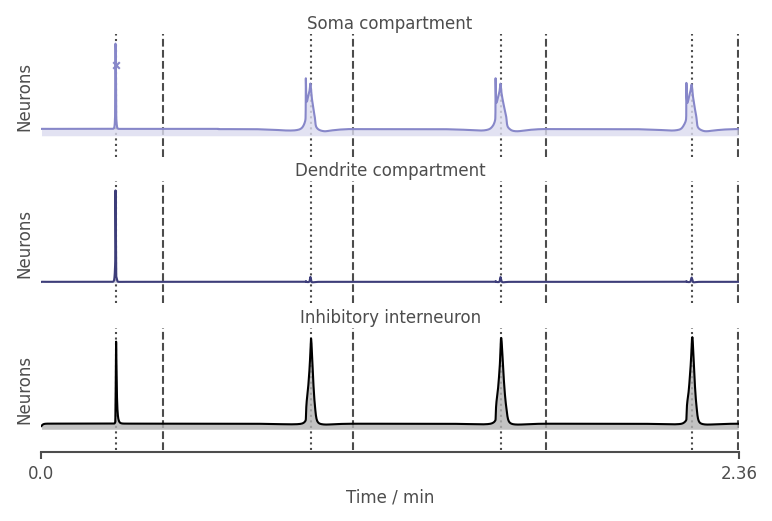

In [6]:
learner, spatial_axes, time_axes = run_manager.learn_1D_BTSP(
    agent_params=agent_params,
    Pyr_params=Pyr_params,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    max_num_steps=NUM_STEPS,
)

Pyrs = learner.Pyrs
Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(Pyrs)

ts_axes = learner.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")

ALL_FIGURES["1-initial_spatial"] = spatial_axes
ALL_FIGURES["1-initial_time"] = time_axes
ALL_FIGURES["1-initial_timeseries"] = ts_axes

In [7]:
learner.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
learner.Pyrs.SomaCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP events applied after 696.00 steps (20.88 sec.)
No neuron had at least two BTSP events triggered.


Speed mean: 24.67 cm/s, std: 3.99 cm/s.


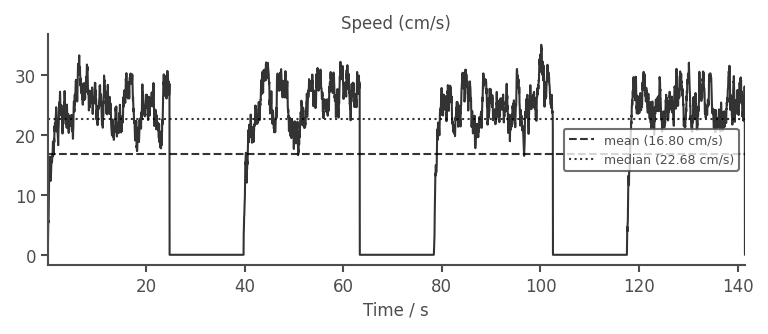

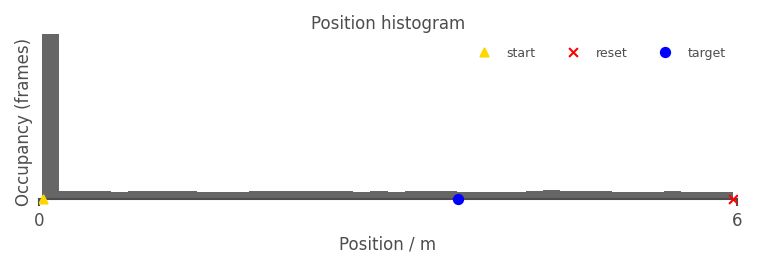

In [8]:
learner.Agent.log_speed_stats(ignore_near_zero=True)
sub_ax_speed = learner.Agent.plot_speed(mark_median=True, mark_mean=True)
sub_ax_occ = learner.Agent.plot_occupancy()

ALL_FIGURES["1-single_speed"] = sub_ax_speed
ALL_FIGURES["1-single_occupancy"] = sub_ax_occ

### Initial direction track groundtruth rate maps

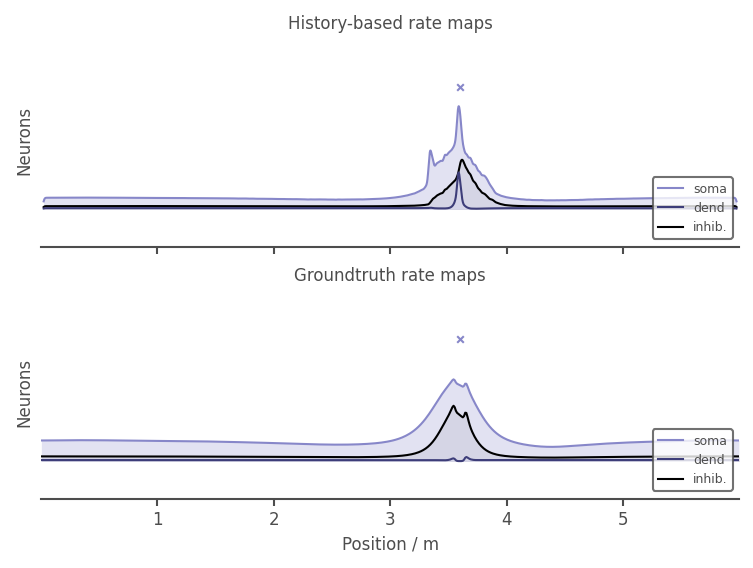

In [9]:
_, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True)
learner.Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
learner.Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Groundtruth rate maps");

ALL_FIGURES["1-initial_rate_maps"] = ax1D

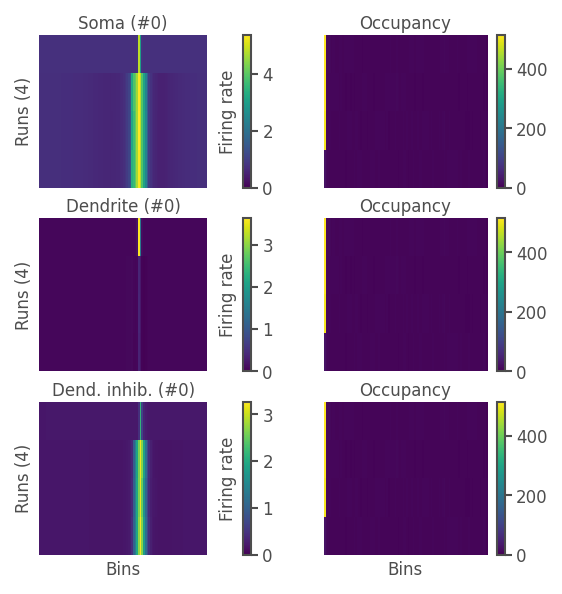

In [10]:
axes = learner.Pyrs.plot_binned_rates()

ALL_FIGURES["1-initial_binned_rates"] = axes

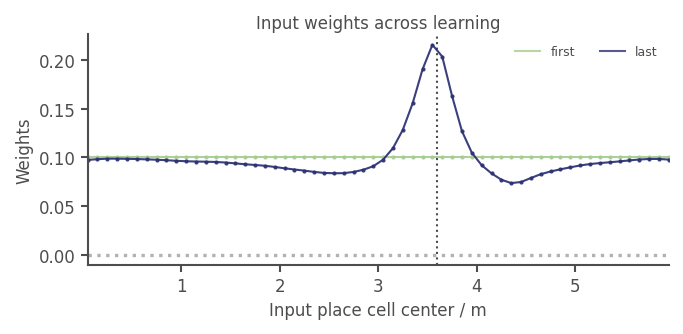

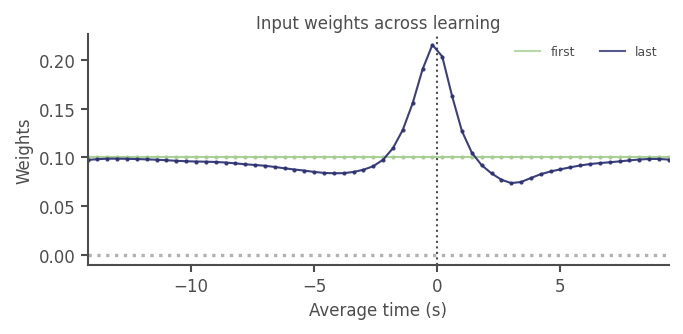

In [11]:
ws = [learner.Pyrs.SomaCompartment.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_input_place_cell_weights(ws, learner.Pyrs.SomaCompartment.inputs["PCs"]["layer"])
sub_ax_time = plot_fcts.plot_1D_input_place_cell_weights(ws, learner.Pyrs.SomaCompartment.inputs["PCs"]["layer"], time_axis=True)

ALL_FIGURES["1-initial_weights"] = sub_ax
ALL_FIGURES["1-initial_weights_time"] = sub_ax_time

## Theoretical kernel

Update 1 regul.: 0.8658 (w)


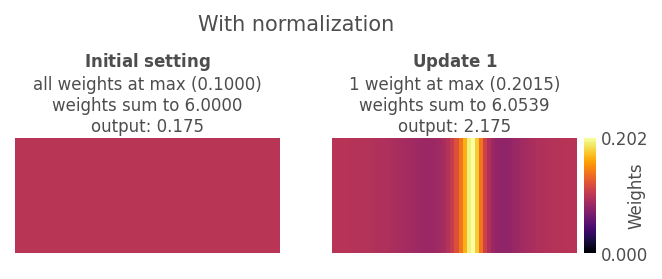

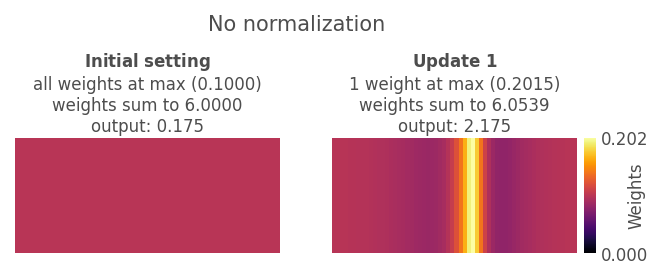

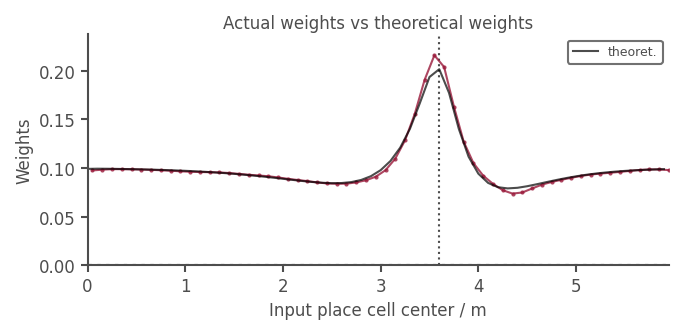

In [12]:
norm_theor_axes, no_norm_theor_axes, comp_sub_ax = plot_fcts.compare_theoretical_and_true_weights(
    Pyrs.SomaCompartment,
    output_fr=4.2, # tuned to match actual weights
)

ALL_FIGURES["BTSP_kernel_norm"] = norm_theor_axes
ALL_FIGURES["BTSP_kernel"] = no_norm_theor_axes
ALL_FIGURES["1-initial_weights_compared"] = comp_sub_ax

### Initial direction inputs and activations

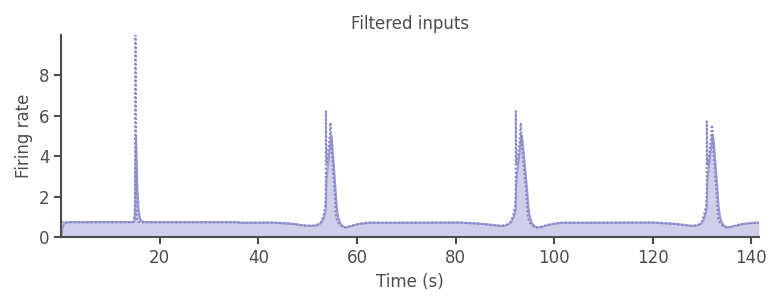

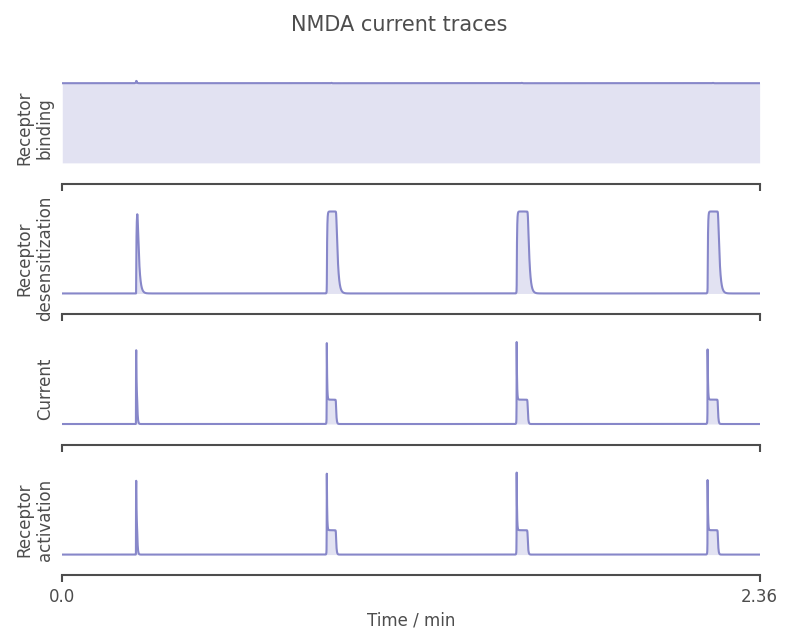

In [13]:
sub_ax, _ = learner.Pyrs.DendriteInhibition.plot_filtered("Pyr_TwoComp_soma")
ax1D = learner.Pyrs.SomaCompartment.NMDACurrent.plot_timeseries(datatypes="all")

ALL_FIGURES["1-initial_filtered_inputs"] = sub_ax
ALL_FIGURES["1-initial_NMDA_current"] = ax1D

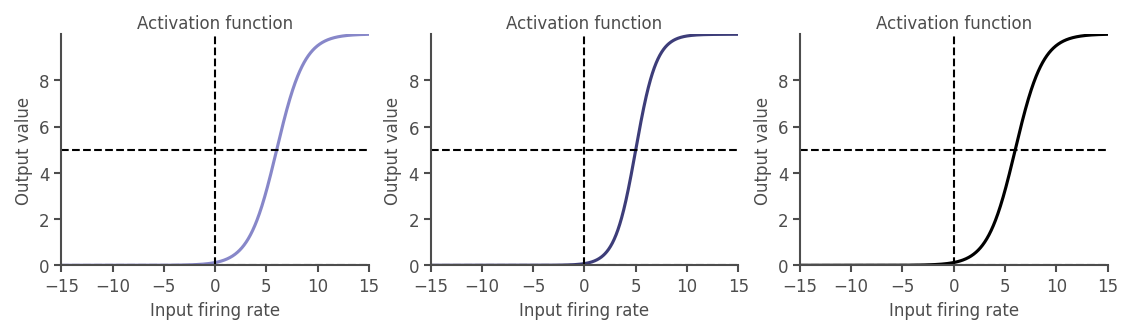

In [14]:
fig, ax1D = plt.subplots(1, 3, figsize=[9, 2])
learner.Pyrs.SomaCompartment.plot_activation_function(sub_ax=ax1D[0])
learner.Pyrs.DendriteCompartment.plot_activation_function(sub_ax=ax1D[1])
learner.Pyrs.DendriteInhibition.plot_activation_function(sub_ax=ax1D[2])

ALL_FIGURES["activation"] = ax1D

### Initial direction BTSP stats

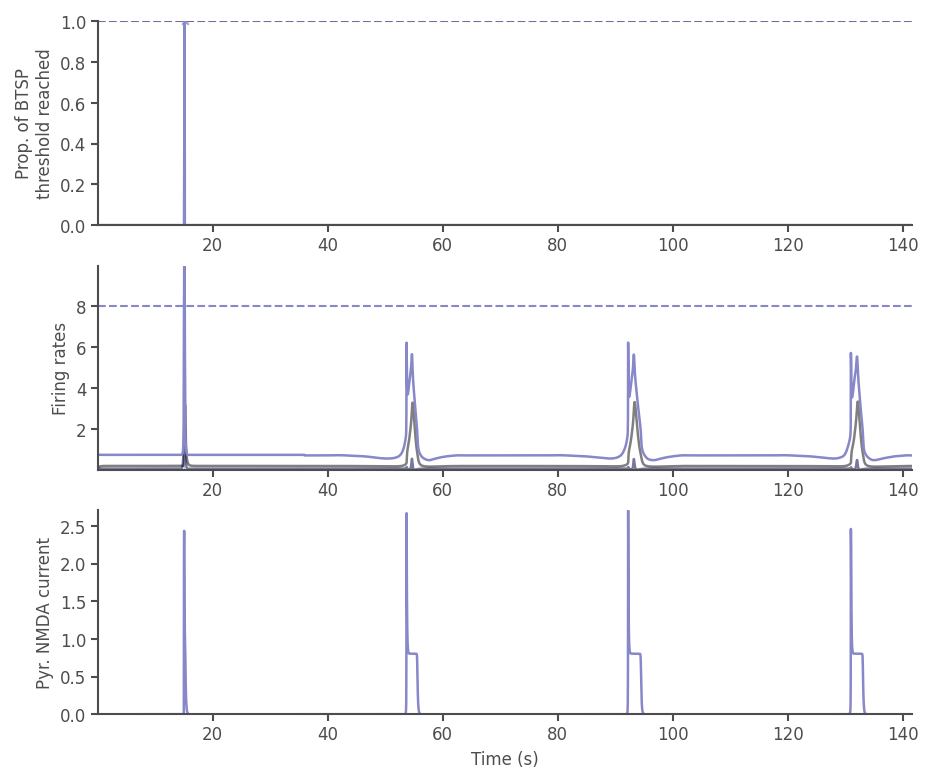

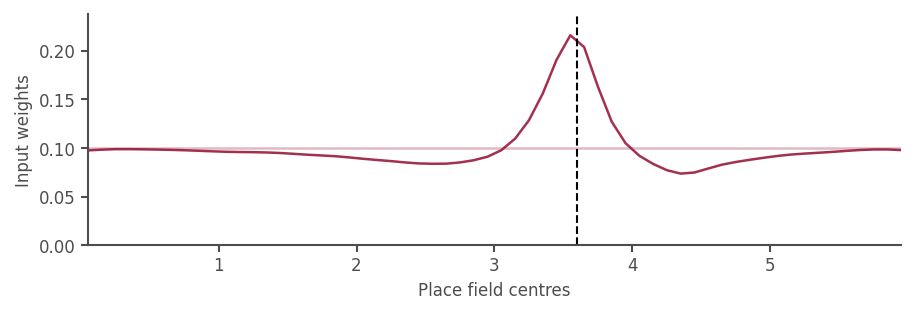

In [15]:
BTSP_ramp_ax1D, PCs_sub_ax = plot_fcts.plot_1D_BTSP_stats(
    learner.Pyrs, 
    recorded_weights=learner.get_recorded_weights(), 
    target_position=target_position
)

ALL_FIGURES["1-initial_BTSP_timeseries"] = BTSP_ramp_ax1D
ALL_FIGURES["1-initial_PC_weights"] = PCs_sub_ax

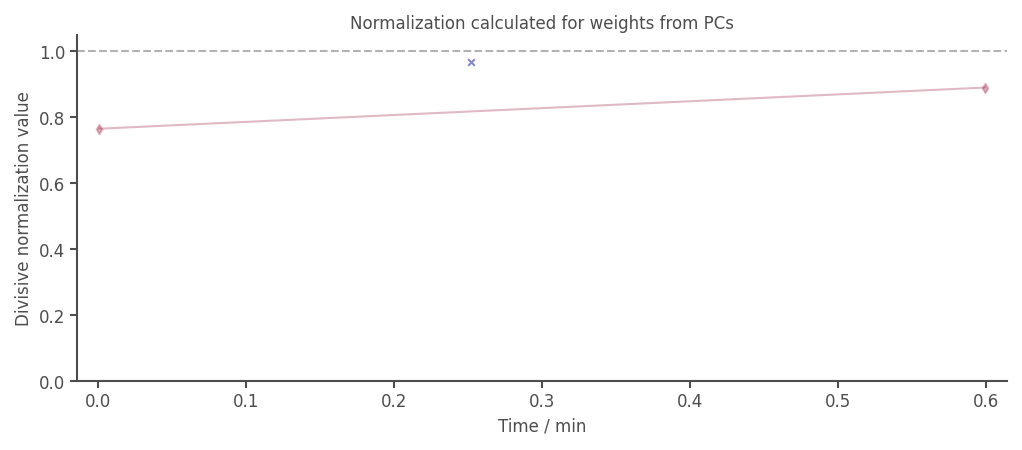

In [16]:
if learner.Pyrs.SomaCompartment.normalize_weights_divisively:
    sub_ax = learner.Pyrs.SomaCompartment.plot_normalization_values_over_time(input_layer="PCs")
    ALL_FIGURES["1-initial_weight_norms"] = sub_ax

### Pre BTSP kernel

#### Plot eligibility trace equivalent

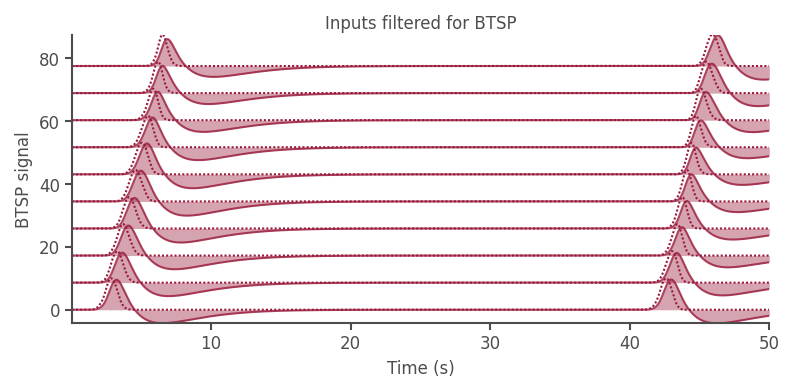

In [17]:
sub_ax = learner.Pyrs.SomaCompartment.plot_filtered_for_BTSP("PCs", t_end=50, chosen_neurons=np.arange(5, 15))
ALL_FIGURES["1-initial_pre_BTSP_filter"] = sub_ax

### Post BTSP kernel

BTSP events applied after 696.00 steps (20.88 sec.) (num steps: 696).


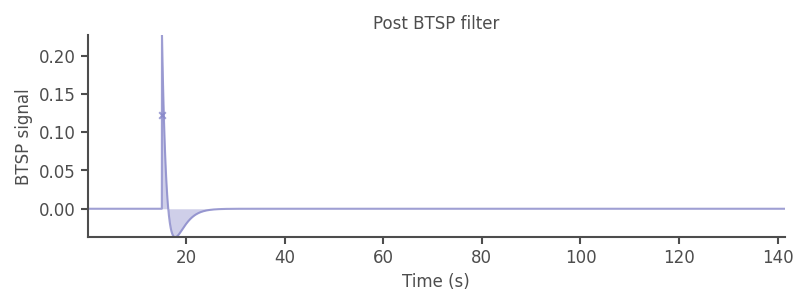

In [18]:
learner.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
sub_ax = learner.Pyrs.SomaCompartment.plot_filtered_for_BTSP()
ALL_FIGURES["1-initial_post_BTSP_filter"] = sub_ax

## 2. Move target
Target moved to a new location after initial BTSP learning.

 26%|██████████                            | 1005/3800 [00:01<00:03, 758.18it/s]

BTSP event recorded for neuron 0 at step 5630 (168.90 sec).


 44%|████████████████▉                     | 1689/3800 [00:02<00:03, 537.40it/s]

BTSP update applied to neuron 0 at step 6324 (189.72 sec).


100%|██████████████████████████████████████| 3800/3800 [00:05<00:00, 719.88it/s]


...

Only reached target 3 times (target: 10).
Trajectory lengths (8) to date: 32.47 +/- 13.14 sec each
Trajectory lengths (8) to date: 1082.25 +/- 437.85 steps each
1 BTSP events triggered (allowed from steps 4717 to 8657): occurred at step 5630.


100%|██████████████████████████████████████| 3800/3800 [00:05<00:00, 670.50it/s]


Finishing last trajectory.


147it [00:00, 748.63it/s]


Only reached target 6 times (target: 10).
Trajectory lengths (11) to date: 34.38 +/- 11.63 sec each
Trajectory lengths (11) to date: 1146.00 +/- 387.79 steps each
1 BTSP events triggered (allowed from steps 4717 to 12605): occurred at step 5630.


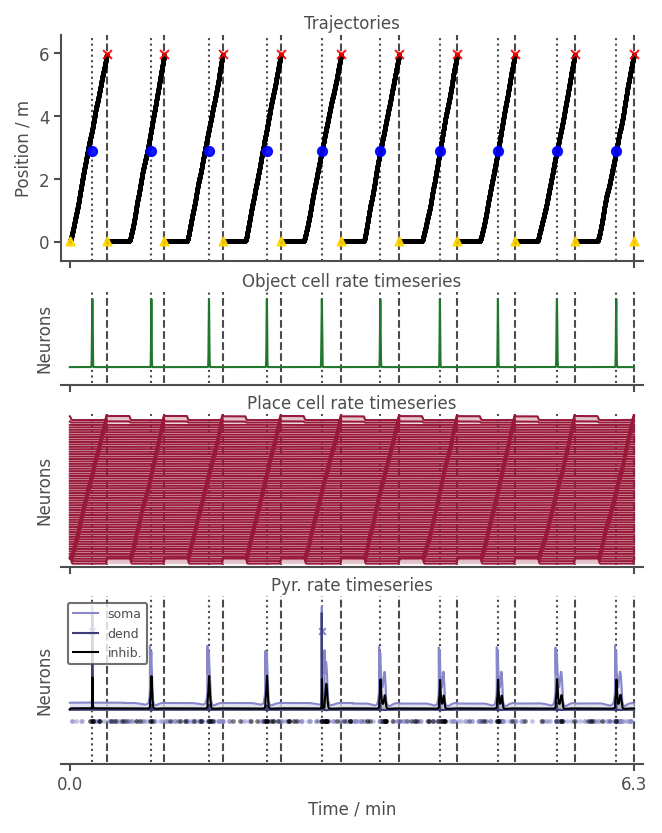

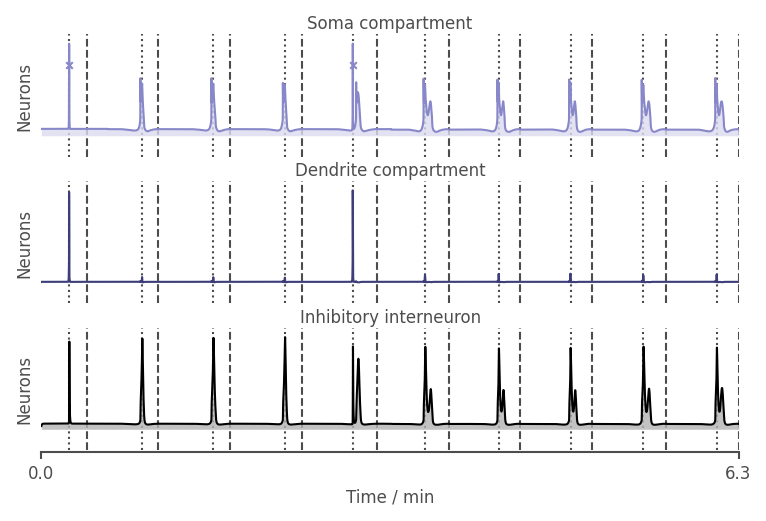

In [19]:
learner_moved = Pyrs
NUM_MOVES = 1
for i in range(NUM_MOVES + 1):
    if i < NUM_MOVES:
        move_by = params_util.MOVE_MID * (i + 1)
        moved_target_position = (target_position - move_by) % params_util.SCALE_LINEAR
        
        move_time = Ag.t
        Ag.set_target_position(moved_target_position)
    
    learner_moved = run_manager.learn_1D_BTSP(
        Pyrs_or_learner=learner_moved,
        num_target_reaches=NUM_MOVES * 10,
        use_Hebbian=USE_HEBBIAN,
        BTSP_on=0,
        max_num_steps=NUM_STEPS,
        plot=False
    )
    
time_axes = plot_fcts.plot_1D_time_info(learner_moved.Pyrs)
ts_axes = learner_moved.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")

ALL_FIGURES["2-moved_time"] = time_axes
ALL_FIGURES["2-moved_timeseries"] = ts_axes

### Moved target groundtruth rate maps

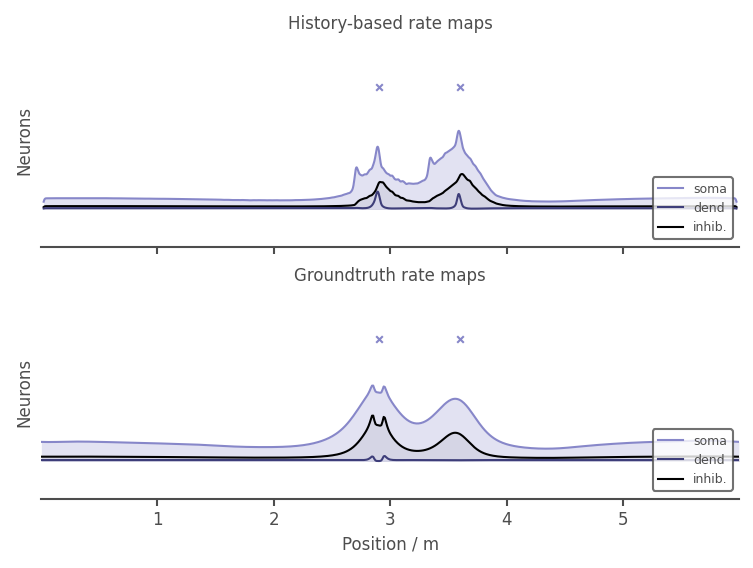

In [20]:
fig, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True)
learner_moved.Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
learner_moved.Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Groundtruth rate maps")

ALL_FIGURES["2-moved_rate_maps"] = ax1D

### Moved target BTSP stats

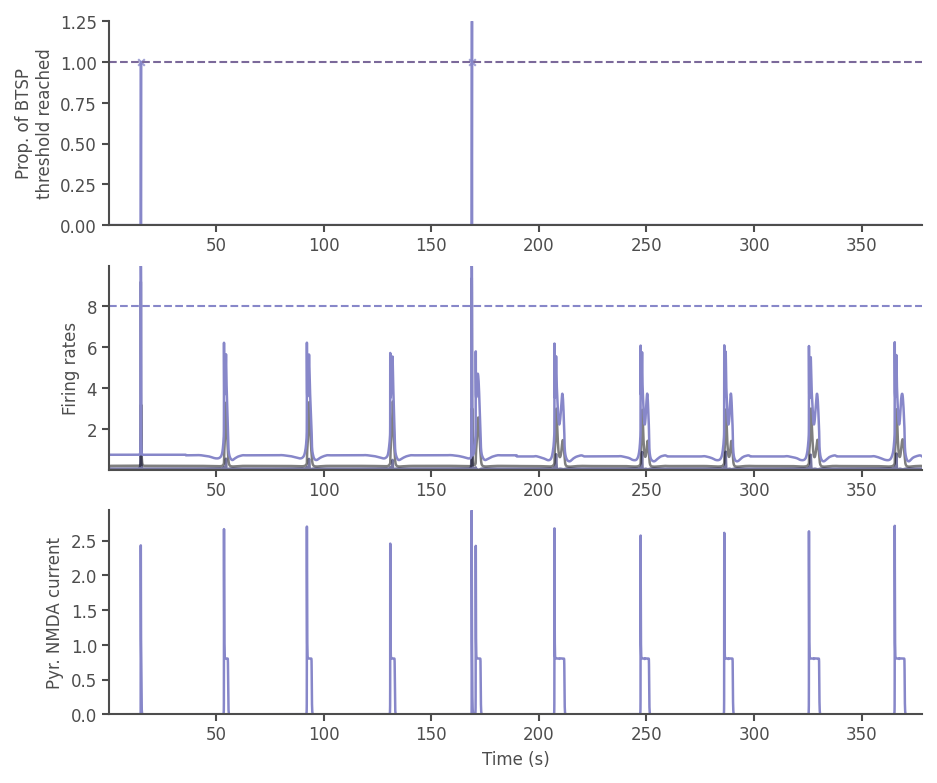

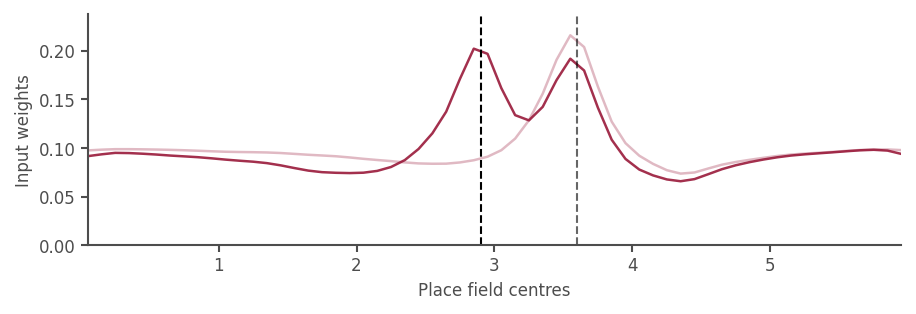

In [21]:
BTSP_ramp_ax1D, PCs_sub_ax = plot_fcts.plot_1D_BTSP_stats(
    learner_moved.Pyrs, 
    recorded_weights=learner_moved.get_recorded_weights(),
    target_position=moved_target_position, 
    other_positions=[target_position]
)

ALL_FIGURES["2-moved_BTSP_timeseries"] = BTSP_ramp_ax1D
ALL_FIGURES["2-moved_PC_weights"] = PCs_sub_ax

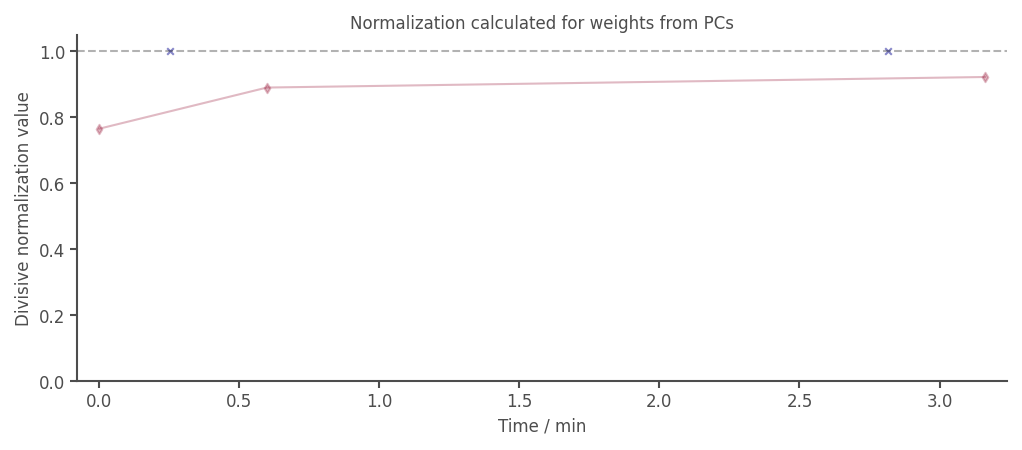

In [22]:
if learner_moved.Pyrs.SomaCompartment.normalize_weights_divisively:
    sub_ax = learner_moved.Pyrs.SomaCompartment.plot_normalization_values_over_time(input_layer="PCs")
    ALL_FIGURES["2-moved_weight_norms"] = sub_ax

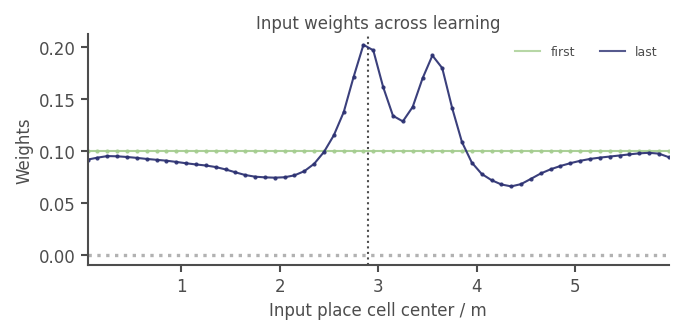

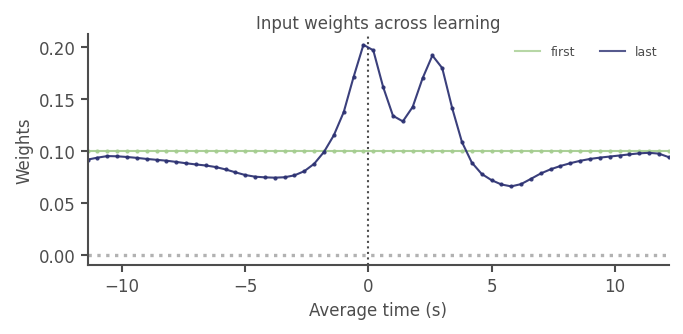

In [23]:
ws = [learner_moved.Pyrs.SomaCompartment.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_input_place_cell_weights(ws, learner_moved.Pyrs.SomaCompartment.inputs["PCs"]["layer"])
sub_ax_time = plot_fcts.plot_1D_input_place_cell_weights(ws, learner_moved.Pyrs.SomaCompartment.inputs["PCs"]["layer"], time_axis=True)

ALL_FIGURES["2-moved_weights"] = sub_ax
ALL_FIGURES["2-moved_weights_time"] = sub_ax_time

BTSP events applied after 696.00 steps (20.88 sec.) (num steps: 696, 696).


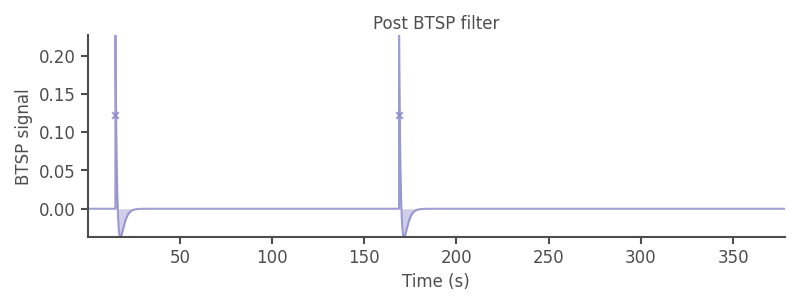

In [24]:
learner_moved.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
sub_ax = learner_moved.Pyrs.SomaCompartment.plot_filtered_for_BTSP()
ALL_FIGURES["2-moved_post_BTSP_filter"] = sub_ax

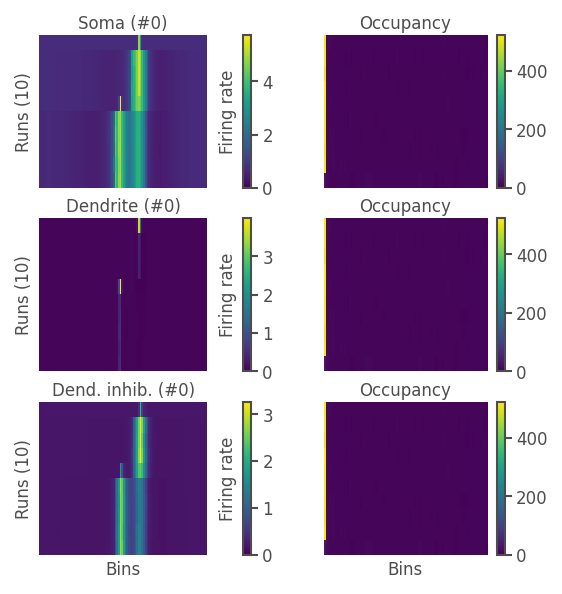

In [25]:
axes = learner_moved.Pyrs.plot_binned_rates()
ALL_FIGURES["2-moved_binned_rates"] = axes

## 3. Switch to back and forth navigation
Agent set to travel back and forth along the track.

100%|██████████████████████████████████████| 7600/7600 [00:11<00:00, 689.61it/s]


Finishing last trajectory.


5519it [00:07, 760.89it/s]


Reached target 10 times.
Trajectory lengths (21) to date: 36.75 +/- 8.80 sec each
Trajectory lengths (21) to date: 1225.05 +/- 293.27 steps each
0 BTSP events triggered (allowed from steps 12606 to 25725).


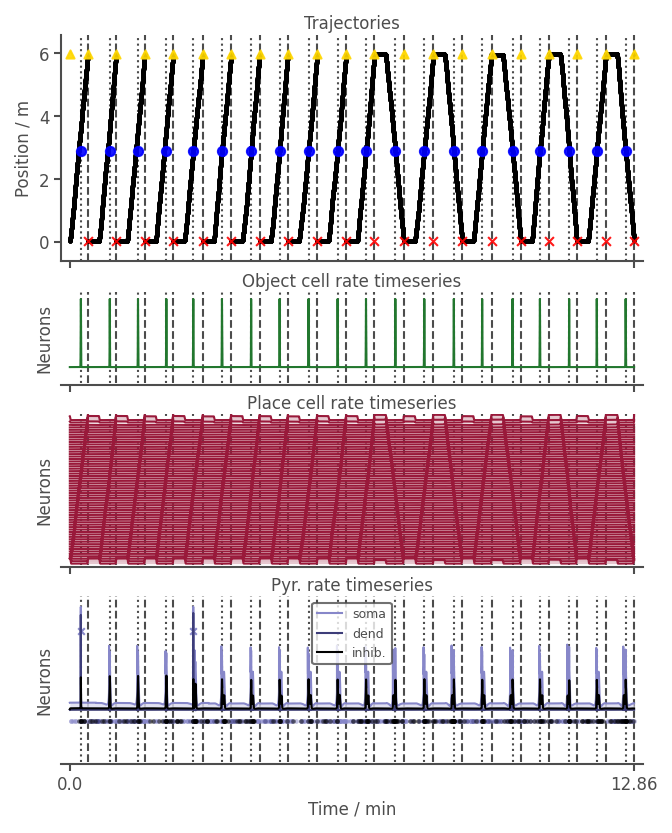

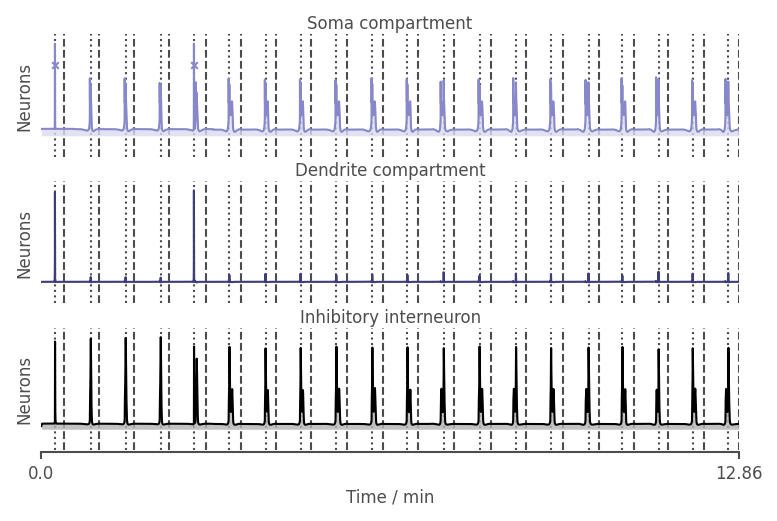

In [26]:
bf_start_time = Ag.t
BF_NUM_STEPS = int(NUM_STEPS * 2)

learner_bf = run_manager.learn_1D_BTSP(
    Pyrs_or_learner=Pyrs,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    max_num_steps=BF_NUM_STEPS,
    reverse=True,
    plot=False
)

time_axes = plot_fcts.plot_1D_time_info(learner_bf.Pyrs)
ts_axes = learner_bf.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")

ALL_FIGURES["3-back_forth_time"] = time_axes
ALL_FIGURES["3-back_forth_timeseries"] = ts_axes

### Back and forth track groundtruth rate maps

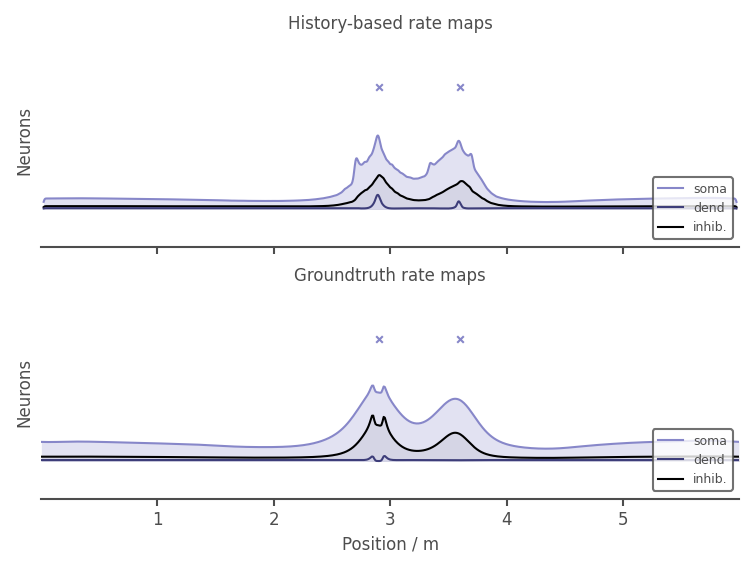

In [27]:
fig, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True)
learner_bf.Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
learner_bf.Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Groundtruth rate maps")

ALL_FIGURES["3-back_forth_rate_maps"] = ax1D

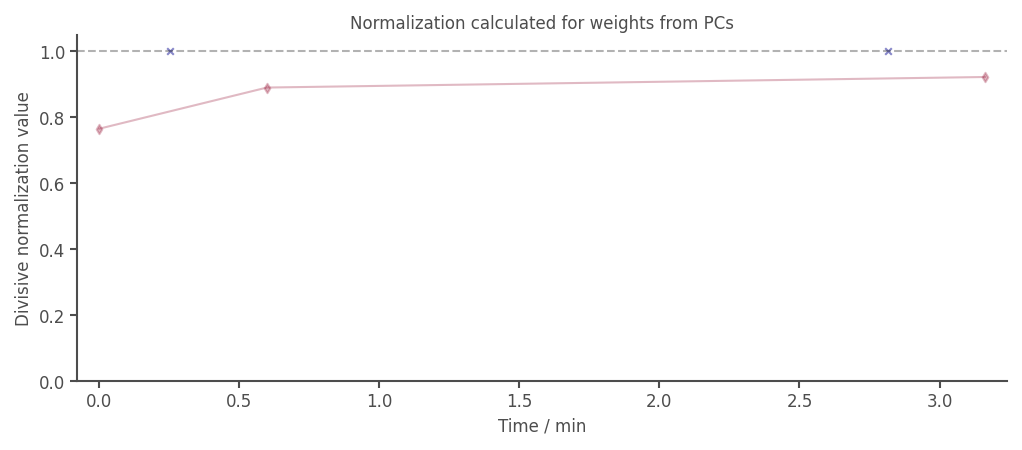

In [28]:
if learner_bf.Pyrs.SomaCompartment.normalize_weights_divisively:
    sub_ax = learner_bf.Pyrs.SomaCompartment.plot_normalization_values_over_time(input_layer="PCs")
    ALL_FIGURES["2-moved_weight_norms"] = sub_ax

### Back and forth track BTSP stats

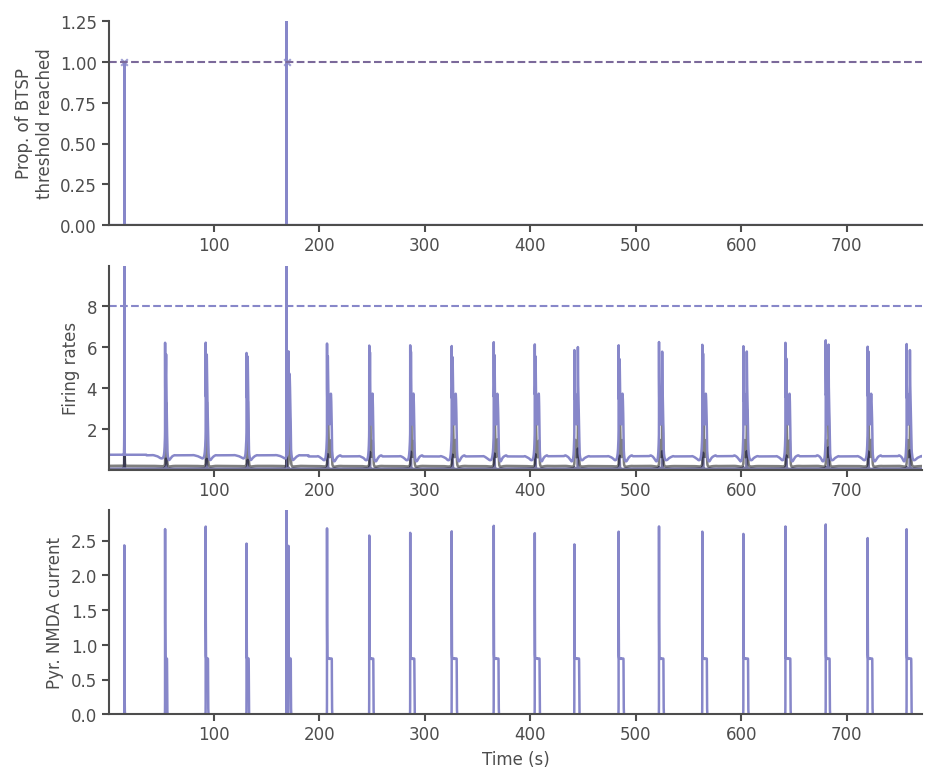

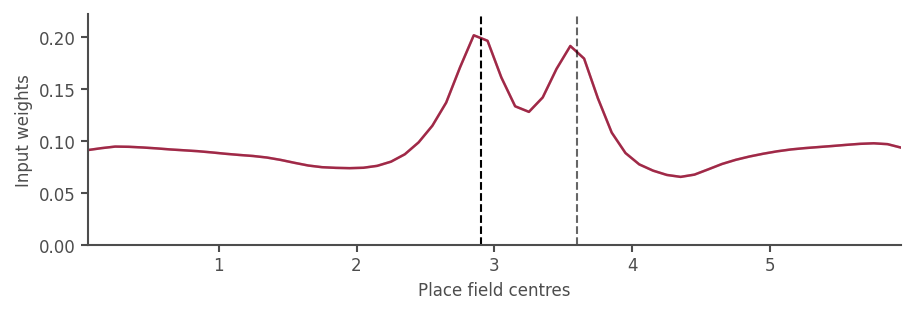

In [29]:
BTSP_ramp_ax1D, PCs_sub_ax = plot_fcts.plot_1D_BTSP_stats(
    learner_bf.Pyrs, 
    recorded_weights=learner_bf.get_recorded_weights(),
    target_position=moved_target_position, 
    other_positions=[target_position]
)

ALL_FIGURES["3-back_forth_BTSP_timeseries"] = BTSP_ramp_ax1D
ALL_FIGURES["3-back_forth_PC_weights"] = PCs_sub_ax

BTSP events applied after 696.00 steps (20.88 sec.) (num steps: 696, 696).


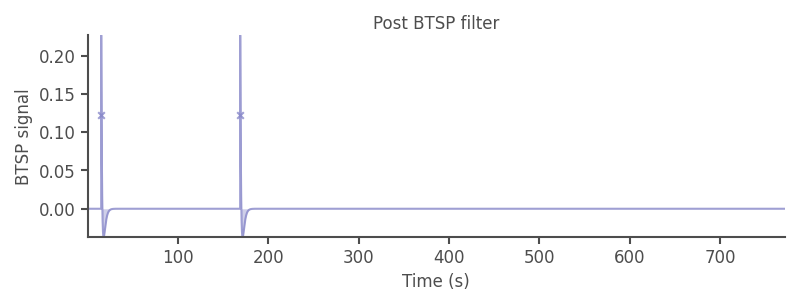

In [30]:
learner_bf.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
sub_ax = learner_bf.Pyrs.SomaCompartment.plot_filtered_for_BTSP()

ALL_FIGURES["3-back_forth_post_BTSP_filter"] = sub_ax

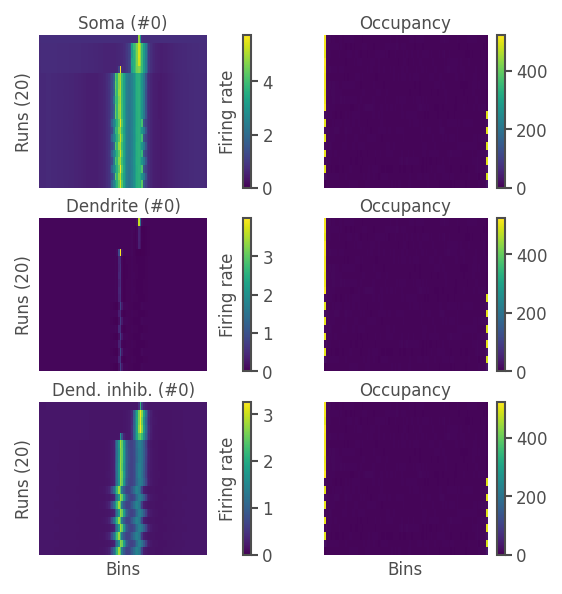

In [31]:
axes = learner_bf.Pyrs.plot_binned_rates()

ALL_FIGURES["3-back_forth_binned_rates"] = axes

## 4. Remove object from track
Object removed from track.

100%|██████████████████████████████████████| 7600/7600 [00:10<00:00, 701.22it/s]


Finishing last trajectory.


284it [00:00, 739.66it/s]


Only reached target 6 times (target: 10).
Trajectory lengths (27) to date: 37.35 +/- 7.84 sec each
Trajectory lengths (27) to date: 1244.85 +/- 261.39 steps each
0 BTSP events triggered (allowed from steps 25726 to 33610).

Target removed.


100%|██████████████████████████████████████| 3800/3800 [00:04<00:00, 761.44it/s]


Finishing last trajectory.


175it [00:00, 736.93it/s]


Only reached target 0 times (target: 10).
Trajectory lengths (30) to date: 37.59 +/- 7.48 sec each
Trajectory lengths (30) to date: 1252.90 +/- 249.18 steps each
0 BTSP events triggered (allowed from steps 33611 to 37586).


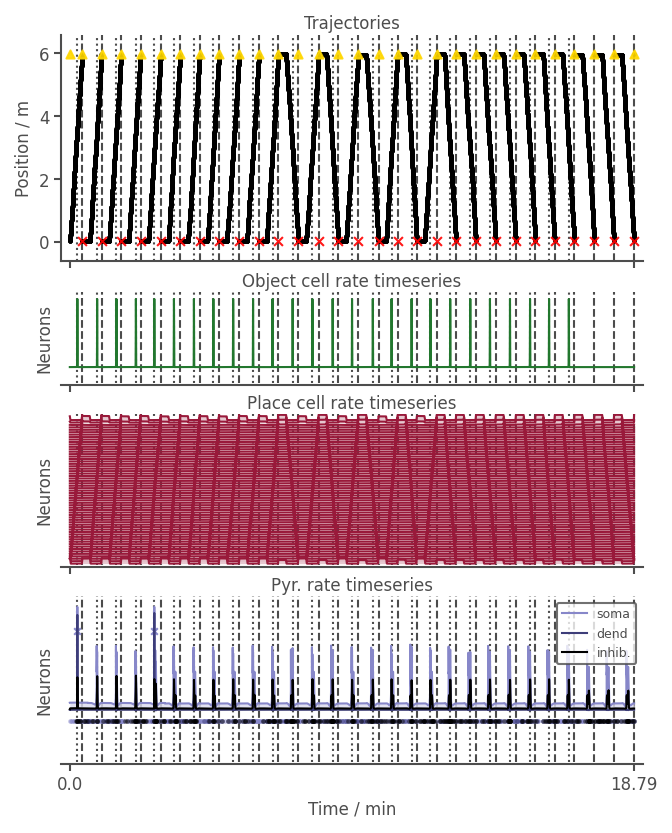

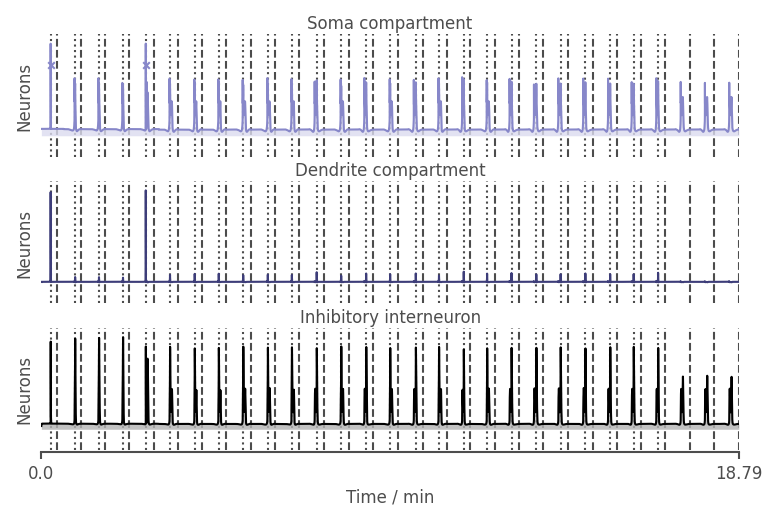

In [32]:
pre_removed_time = Ag.t
learner_pre_removed = run_manager.learn_1D_BTSP(
    Pyrs_or_learner=Pyrs,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    num_trajectories=4,
    max_num_steps=NUM_STEPS * 2, # excess
    plot=False
)

print("\nTarget removed.")
Ag.set_target_position(None)
Objs.set_to_dummy()
removed_time = Ag.t
        
learner_post_removed = run_manager.learn_1D_BTSP(
    Pyrs_or_learner=Pyrs,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    max_num_steps=NUM_STEPS,
    plot=False
)

time_axes = plot_fcts.plot_1D_time_info(learner_post_removed.Pyrs)
ts_axes = learner_post_removed.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")

ALL_FIGURES["4-removed_time"] = time_axes
ALL_FIGURES["4-removed_timeseries"] = ts_axes

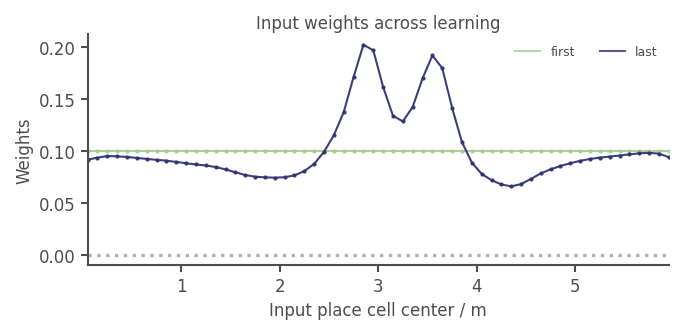

In [33]:
ws = [Pyrs.SomaCompartment.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_input_place_cell_weights(ws, Pyrs.SomaCompartment.inputs["PCs"]["layer"])

ALL_FIGURES["4-removed_weights"] = sub_ax

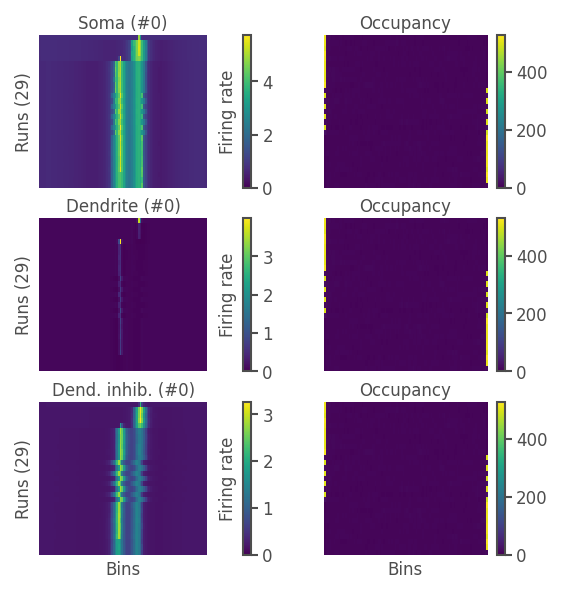

In [34]:
axes = Pyrs.plot_binned_rates()

ALL_FIGURES["4-removed_binned_rates"] = axes

## Before / After

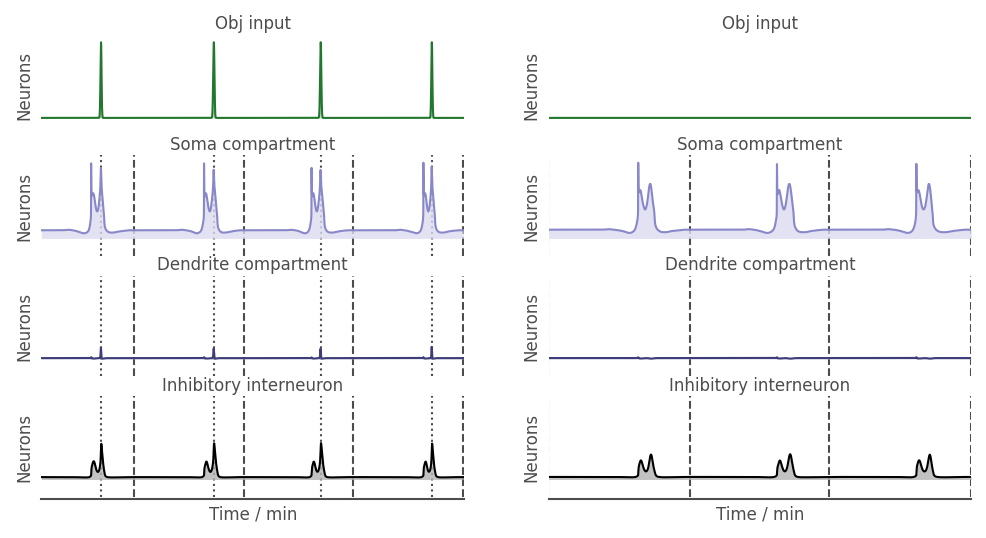

In [35]:
axes = plot_fcts.plot_pre_post_responses(Pyrs, Objs, ref_time=removed_time, pre=2.5 * 60)
ALL_FIGURES["4-removed_pre_post"] = axes

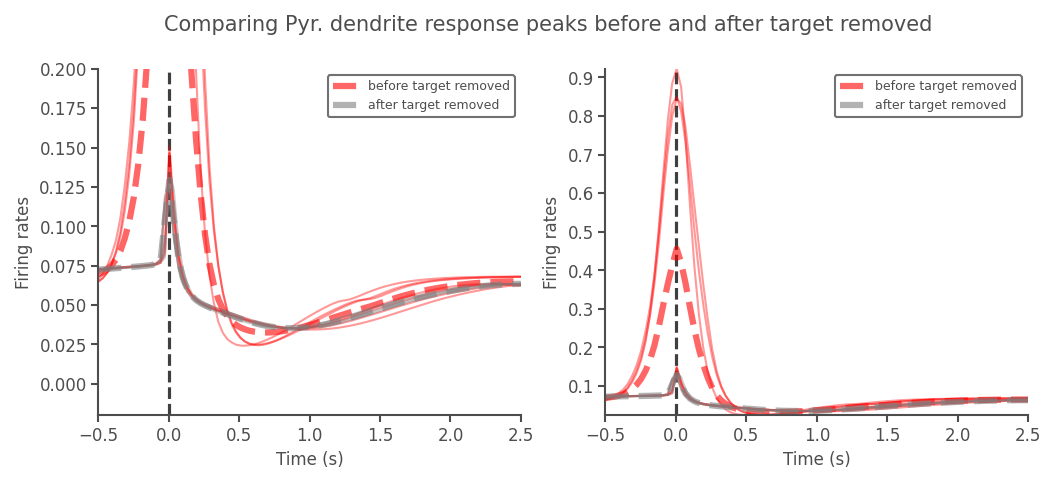

In [36]:
fig, ax1D = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=False)

pre = 2.5 * 60
pts_btw = 100
all_ylims = [(-0.02, 0.2), None]

for i, ylims in enumerate(all_ylims):
    plot_fcts.plot_pre_post_dendrite_peaks(
        Pyrs, 
        ref_time=removed_time, 
        pre=pre,
        ylims=ylims,
        together=True, 
        label="target removed", 
        ax=ax1D[i],
        pts_btw=pts_btw
    )

ALL_FIGURES["4-removed_pre_post_dendrite"] = ax1D

## 6. Change running speed

In [37]:
def get_speed(speed="slow"):
    
    base_num_steps = NUM_STEPS * 4
    if speed == "slow":
        speed_mean = params_util.SPEED_MEAN_LINEAR / 1.5
        speed_std = params_util.SPEED_MEAN_LINEAR / 8
        num_steps_use = int(base_num_steps * 1.5)
    elif speed == "fast":
        speed_mean = params_util.SPEED_MEAN_LINEAR * 1.5
        speed_std = params_util.SPEED_MEAN_LINEAR / 16
        num_steps_use = int(base_num_steps / 1.5)
    elif speed == "variable":
        speed_mean = params_util.SPEED_MEAN_LINEAR
        speed_std = params_util.SPEED_MEAN_LINEAR
        num_steps_use = base_num_steps
    else:
        raise ValueError(f"speed {speed} not recognized.")

    return speed_mean, speed_std, num_steps_use

Running at slow speed.


  3%|█▏                                    | 688/22800 [00:00<00:29, 755.53it/s]

BTSP event recorded for neuron 0 at step 582 (17.46 sec).


  6%|██▏                                  | 1373/22800 [00:01<00:28, 755.11it/s]

BTSP update applied to neuron 0 at step 1276 (38.28 sec).


...

100%|████████████████████████████████████| 15200/15200 [00:22<00:00, 679.09it/s]


Finishing last trajectory.


258it [00:00, 746.34it/s]


Only reached target 14 times (target: 16).
Trajectory lengths (14) to date: 33.13 +/- 11.90 sec each
Trajectory lengths (14) to date: 1104.21 +/- 396.51 steps each
2 BTSP events triggered (allowed from steps 0 to 15458): occurred between steps 6151 and 6847, inclusively.
Speed mean: 30.99 cm/s, std: 19.58 cm/s.


/home/cgillon/homedir/predhpc/predhpc/util/plot_util.py:1029: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, axes = plt.subplots(


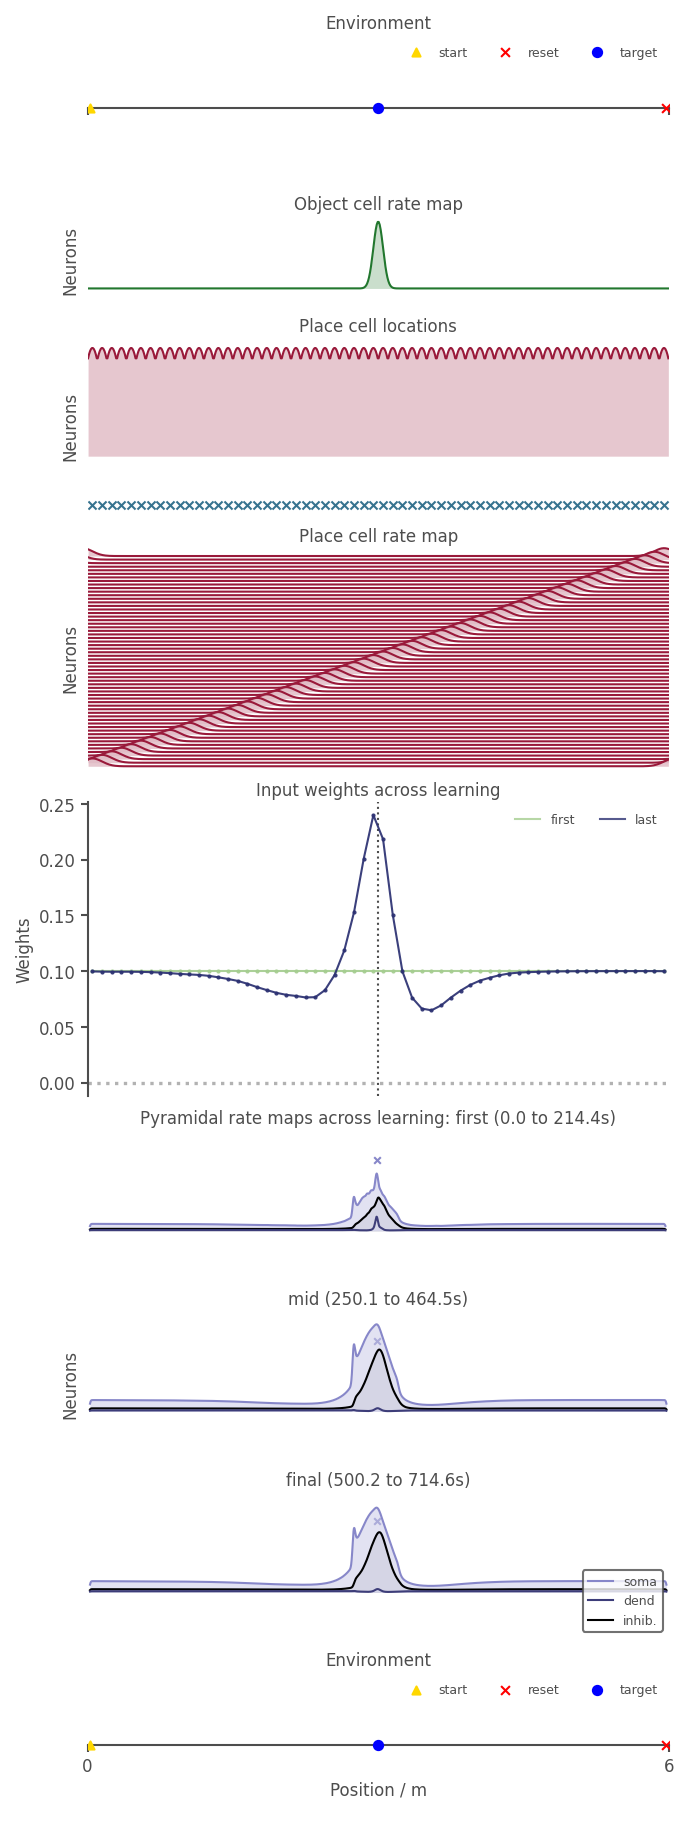

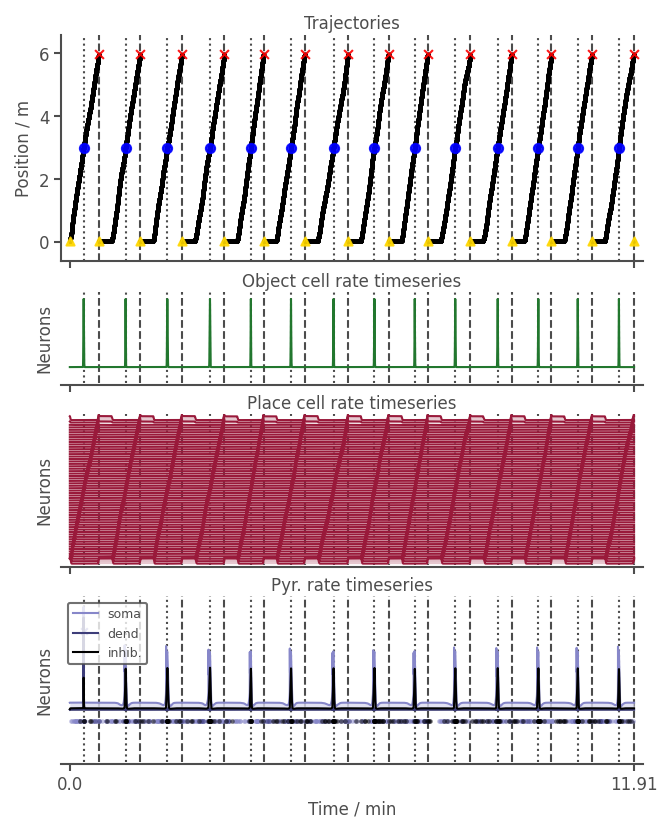

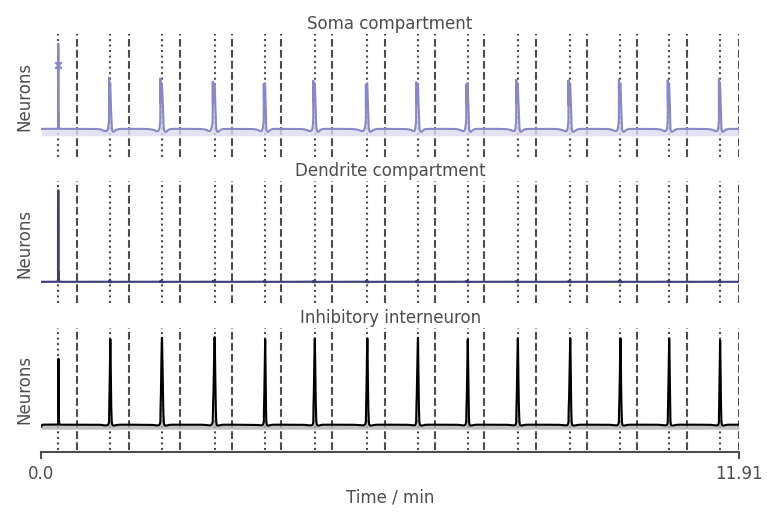

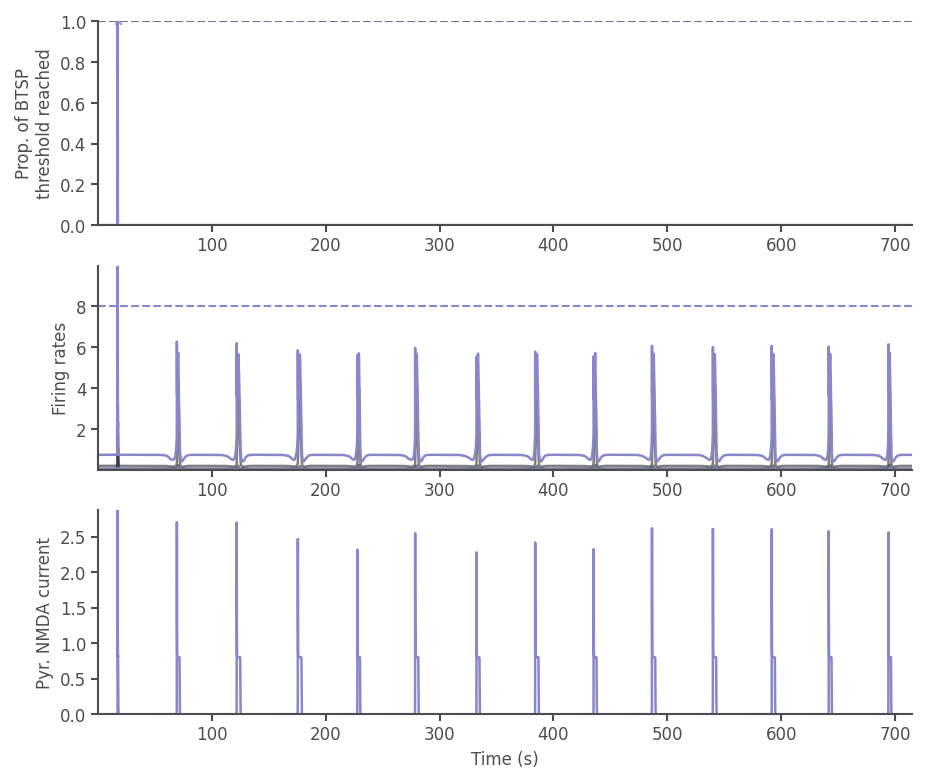

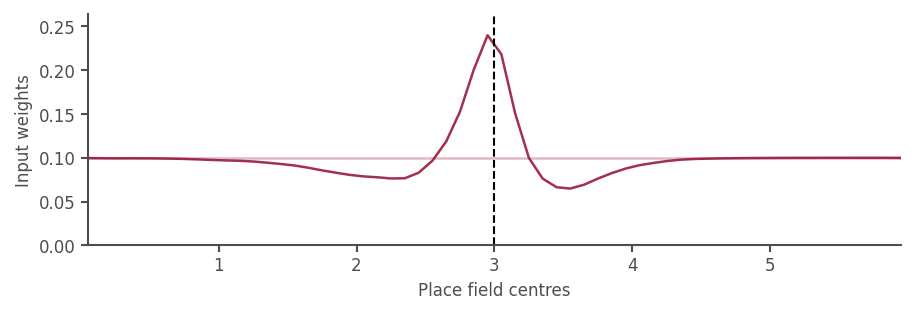

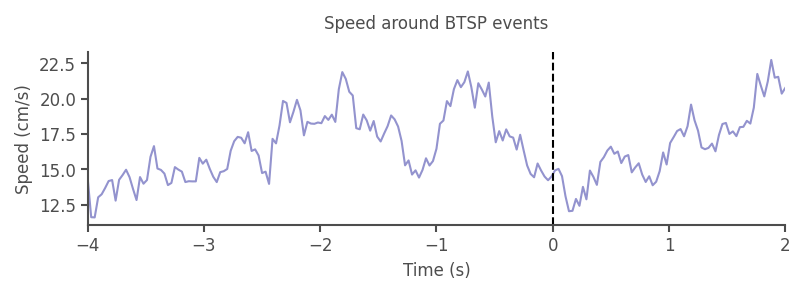

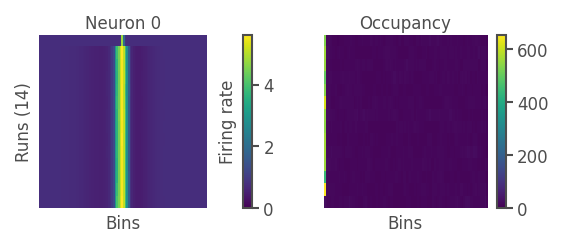

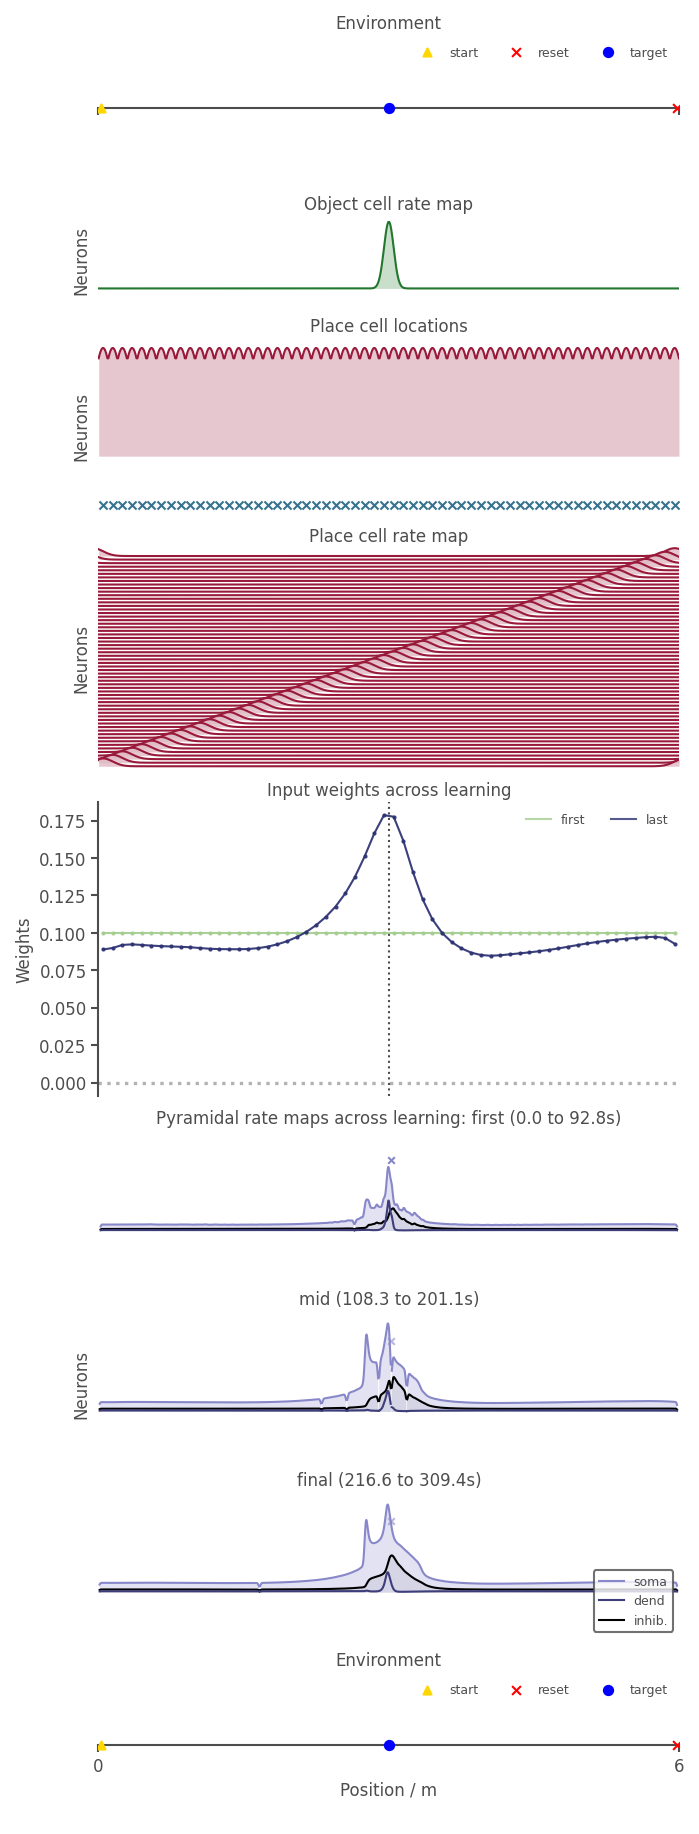

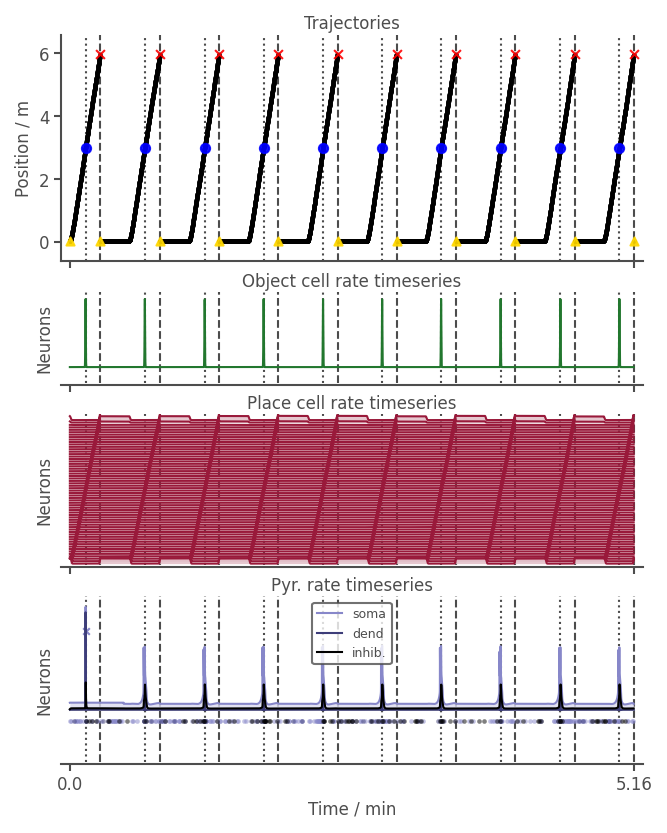

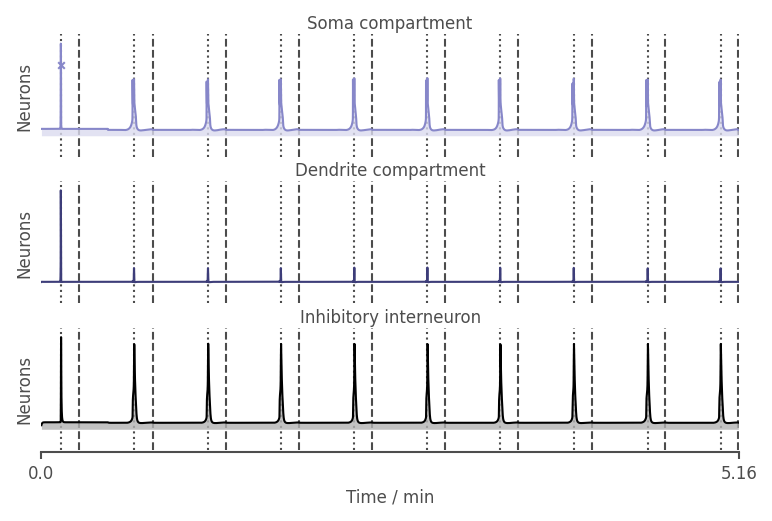

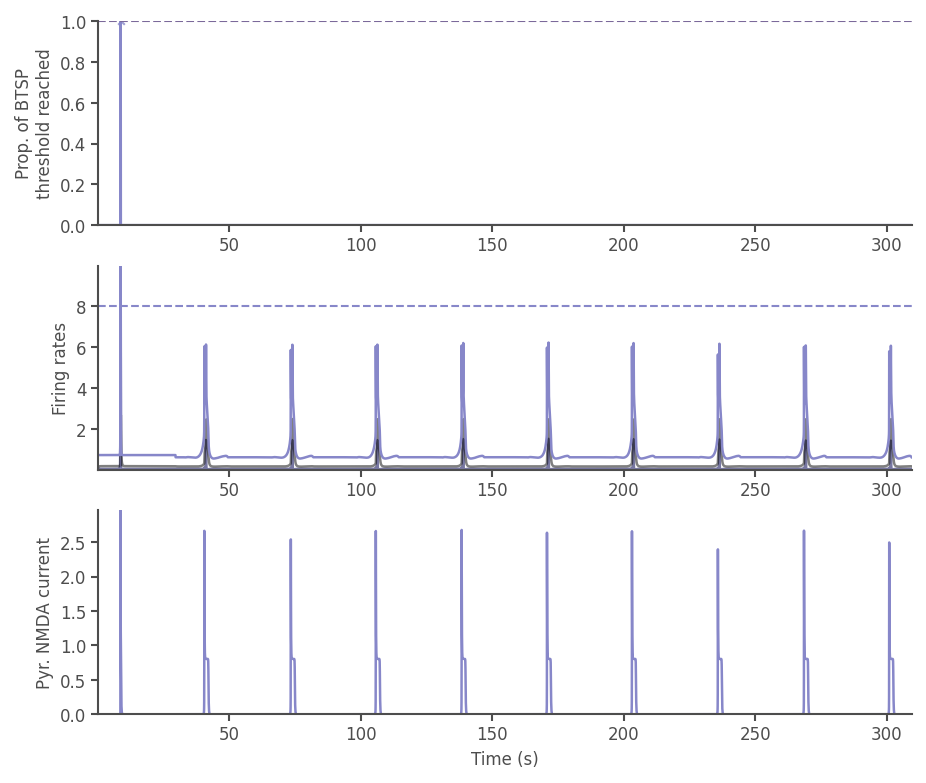

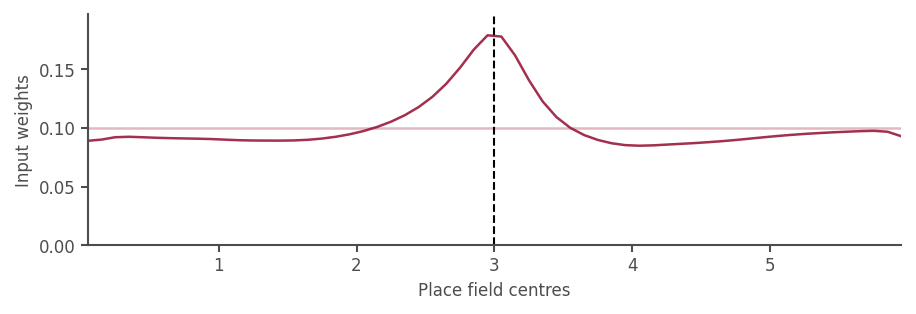

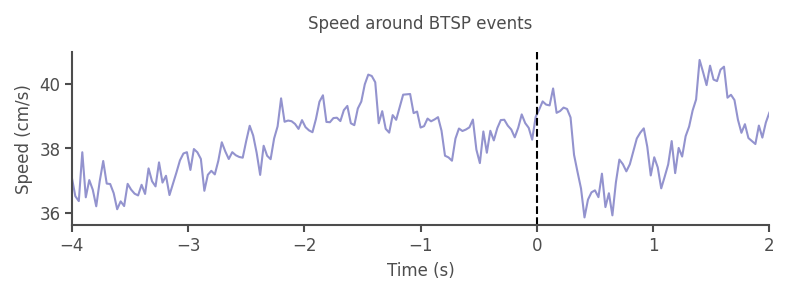

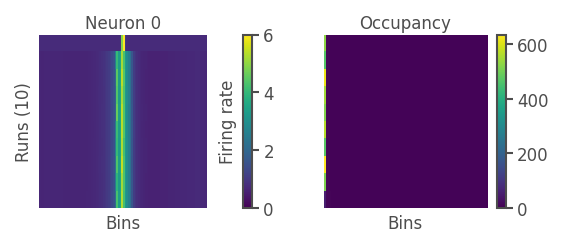

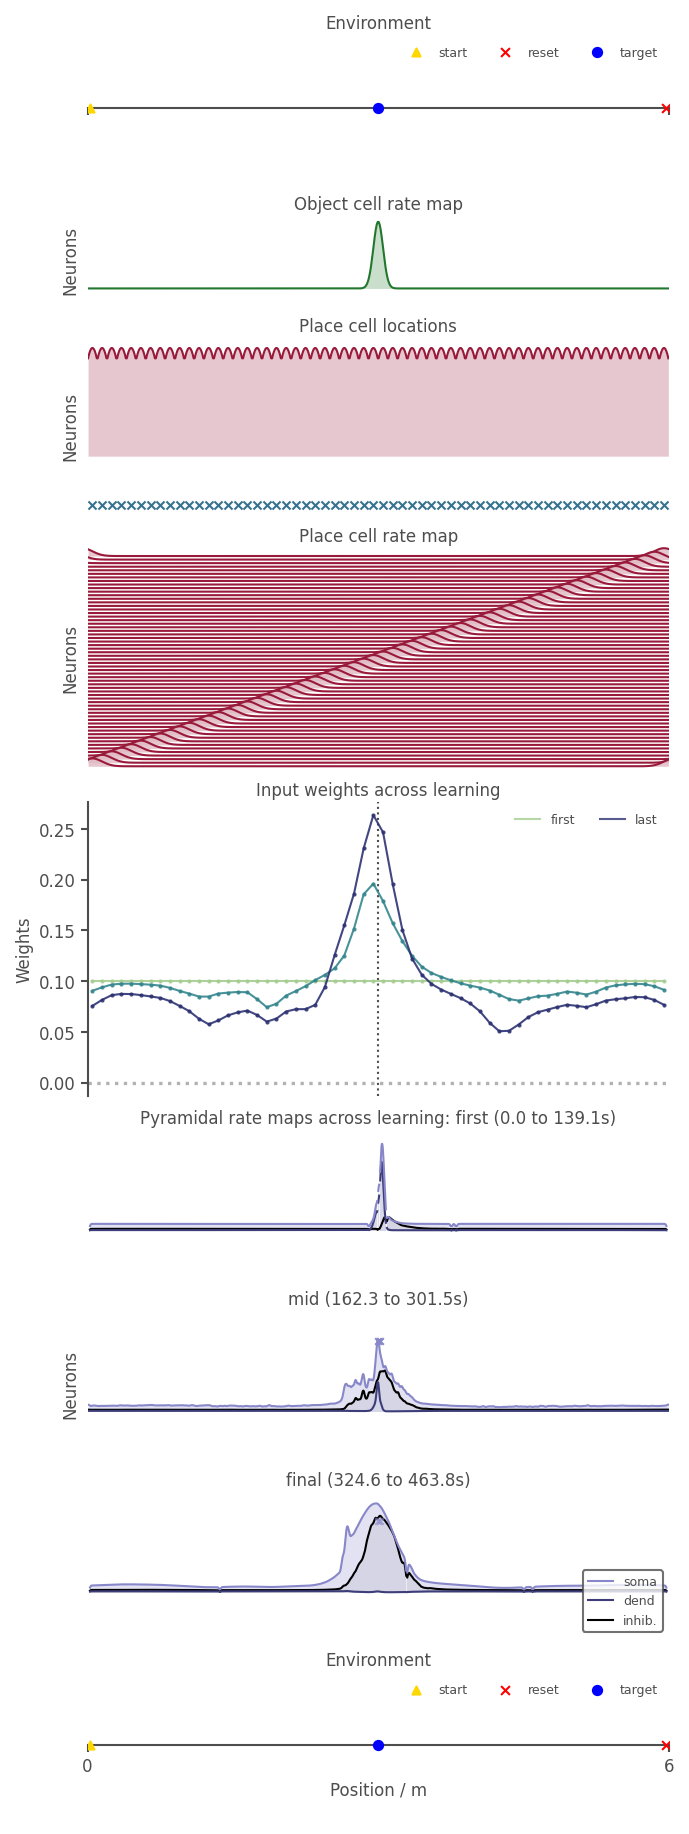

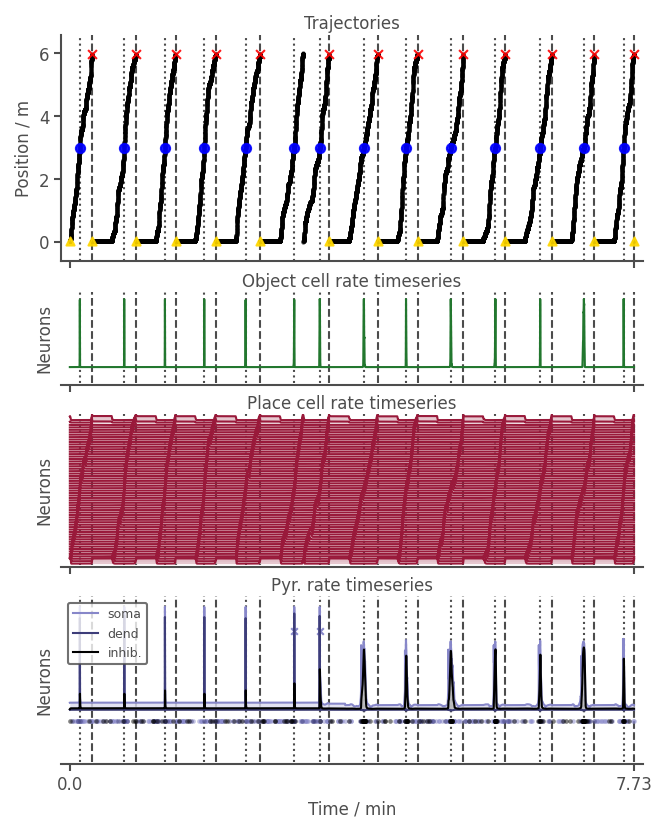

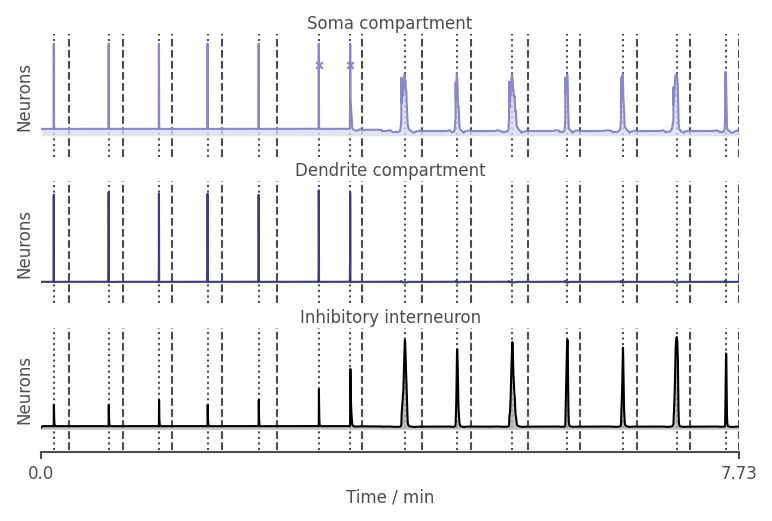

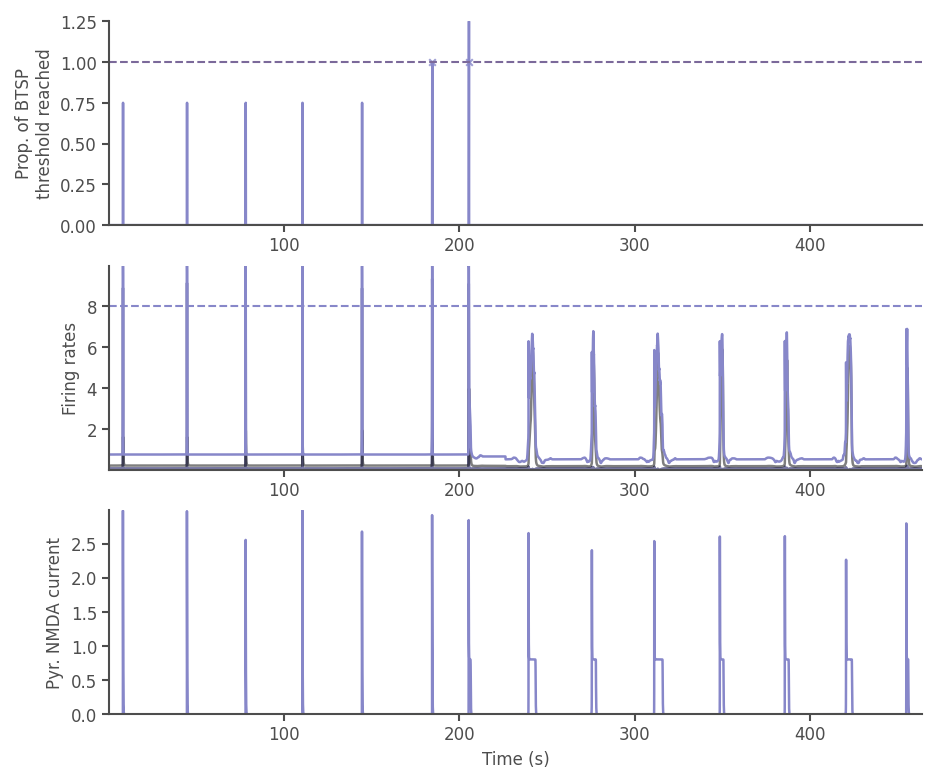

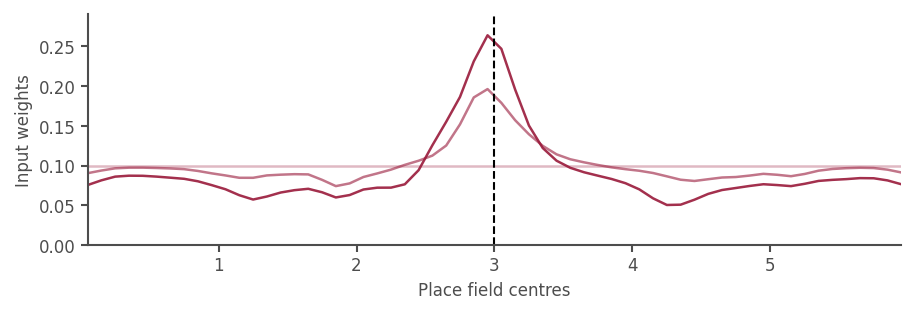

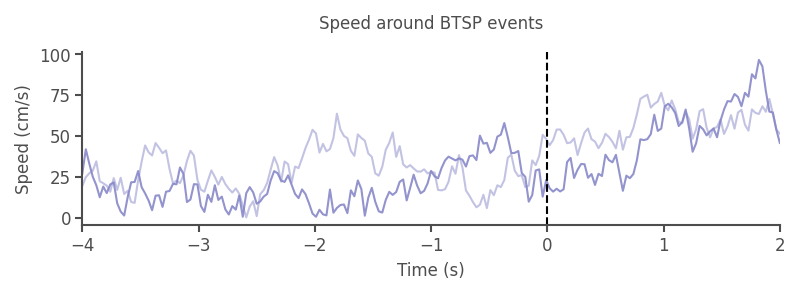

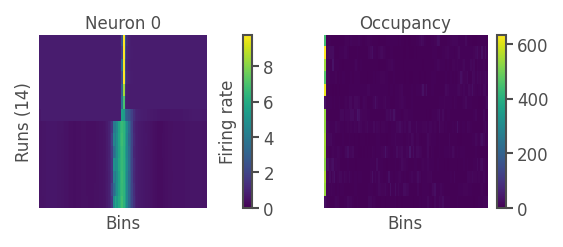

In [38]:
speed_learners_all = list()
for i, speed in enumerate(["slow", "fast", "variable"]):
    space = "\n" if i > 0 else ""
    print(f"{space}Running at {speed} speed.")

    speed_mean, speed_std, num_steps_use = get_speed(speed)
    speed_target_position = np.asarray([params_util.SCALE_LINEAR / 2])
    agent_params_speed = params_util.get_agent_params(
        environment="linear",
        target_position=speed_target_position,
        speed_mean=speed_mean,
        speed_std=speed_std,
    )
    
    speed_learner, spatial_axes_speed, time_axes_speed = run_manager.learn_1D_BTSP(
        agent_params=agent_params_speed,
        Pyr_params=Pyr_params,
        use_Hebbian=USE_HEBBIAN,
        BTSP_on=0,
        max_num_steps=num_steps_use,
        num_target_reaches=16,
    )
    speed_learners_all.append(speed_learner)
    
    speed_learner.Agent.log_speed_stats(ignore_near_zero=True)
    
    ts_axes_speed = speed_learner.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")
   
    BTSP_ramp_ax1D_speed, PCs_sub_ax_speed = plot_fcts.plot_1D_BTSP_stats(
        speed_learner.Pyrs, 
        recorded_weights=speed_learner.get_recorded_weights(), 
        target_position=speed_target_position
    )

    BTSP_speed_sub_ax = speed_learner.Pyrs.SomaCompartment.plot_around_BTSP(datatype="speed")

    binned_rates_axes = speed_learner.Pyrs.SomaCompartment.plot_binned_rates(vel_sign_smooth=39) # high threshold

    ALL_FIGURES[f"5-spatial_{speed}"] = spatial_axes_speed
    ALL_FIGURES[f"5-time_{speed}"] = time_axes_speed
    ALL_FIGURES[f"5-timeseries_{speed}"] = ts_axes_speed
    ALL_FIGURES[f"5-BTSP_timeseries_{speed}"] = BTSP_ramp_ax1D_speed
    ALL_FIGURES[f"5-PC_weights_{speed}"] = PCs_sub_ax
    ALL_FIGURES[f"5-BTSP_speed_{speed}"] = BTSP_speed_sub_ax
    ALL_FIGURES[f"5-binned_rates_{speed}"] = binned_rates_axes

## 7. Save and animate

### Save figures

In [39]:
SAVE = True

In [40]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        if isinstance(ax, np.ndarray):
            fig = ax.ravel()[0].figure
        else:
            fig = ax.figure
        plot_util.save_figure(fig, key, save=True)        

Saving 64 figures...
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/1-initial_spatial_1432.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/1-initial_time_1432.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/1-initial_timeseries_1432.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/1-single_speed_1432.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/1-single_occupancy_1432.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/1-initial_rate_maps_1432.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/1-initial_binned_rates_1432.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/1-initial_weights_1432.png  & .svg
Figure saved to /home/

### Animate

In [41]:
ANIMATE = True

In [42]:
if ANIMATE:
    all_learners = [
        learner, 
        learner_moved, 
        learner_bf, 
        learner_pre_removed, 
        learner_post_removed
    ]

    all_weight_dicts = [curr_learner.get_recorded_weights() for curr_learner in all_learners]
    combined_weights = {
        key: np.concatenate([weight_dict[key] for weight_dict in all_weight_dicts]).tolist() 
        for key in all_weight_dicts[0].keys()
    }
    
    all_animate_kwargs = {
        "Pyrs": Pyrs,
        "Pyrs_weights": combined_weights["weights"],
        "Pyrs_weights_t": combined_weights["time"],
        "fps": 8,
        "speed_up": 3,
        "previous_target_positions": [target_position, moved_target_position],
        "target_move_times": [move_time, removed_time],
        "embed_limit": 40.0,
        "autosave": True,
    }
    
    if (Ag.start_position > Ag.reset_position).all():
        Ag.reverse()

Animation saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/1-initial_timeseries_1433.mp4  & .gif
Animation took 5.61 min. to create.


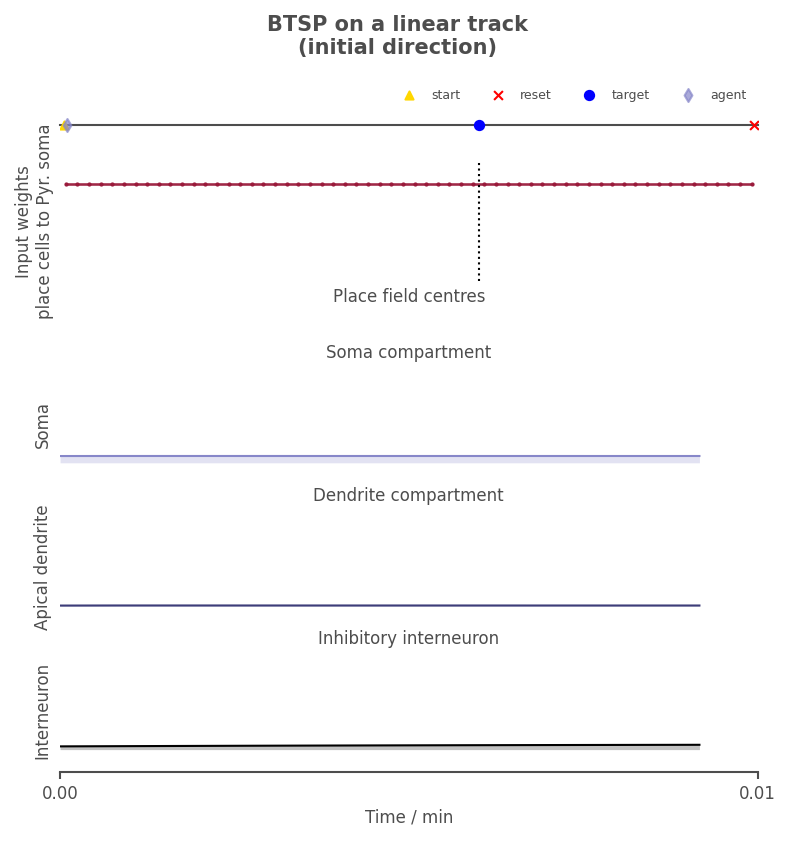

In [43]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=0, 
        t_end=move_time, 
        savename="1-initial_timeseries",
        addendum="initial direction",
        **all_animate_kwargs
        )
    anim

Animation saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/2-moved_timeseries_1438.mp4  & .gif
Animation took 10.07 min. to create.


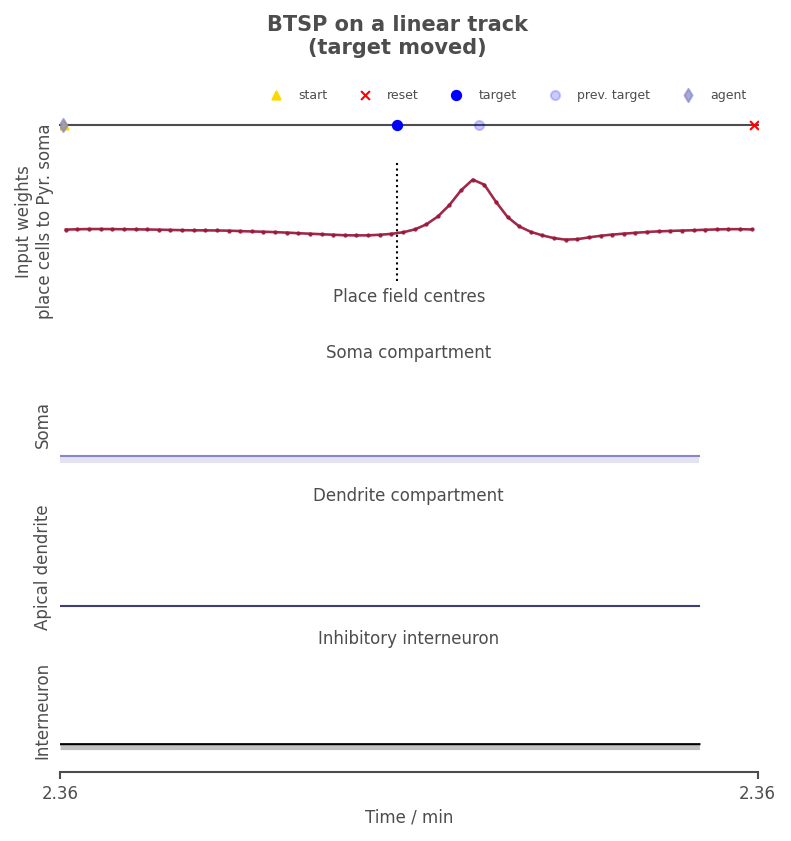

In [44]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=move_time, 
        t_end=bf_start_time, 
        savename="2-moved_timeseries",
        addendum="target moved",
        **all_animate_kwargs
        )
    anim

Animation saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/3-back_forth_timeseries_1448.mp4  & .gif
Animation took 17.42 min. to create.


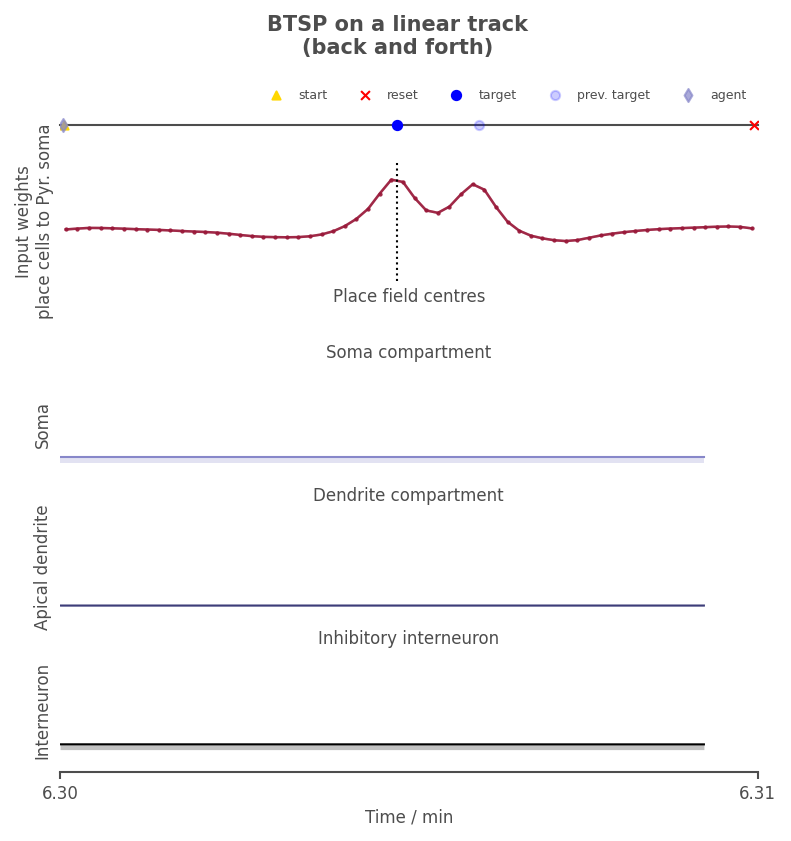

In [45]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=bf_start_time, 
        t_end=pre_removed_time, 
        savename="3-back_forth_timeseries",
        addendum="back and forth",
        **all_animate_kwargs
        )
    anim

Animation saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/4-removed_timeseries_1506.mp4  & .gif
Animation took 15.99 min. to create.


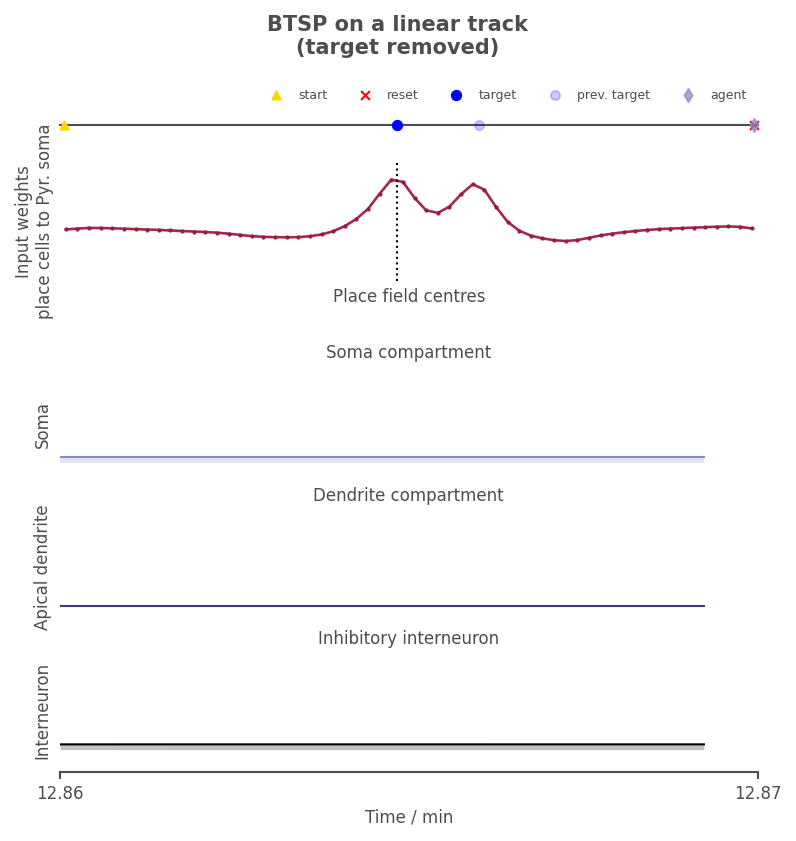

In [46]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=pre_removed_time, 
        t_end=None, 
        savename="4-removed_timeseries",
        addendum="target removed",
        **all_animate_kwargs
        )
    anim

Animation saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_05_19/5-full_timeseries_1522.mp4  & .gif
Animation took 56.57 min. to create.


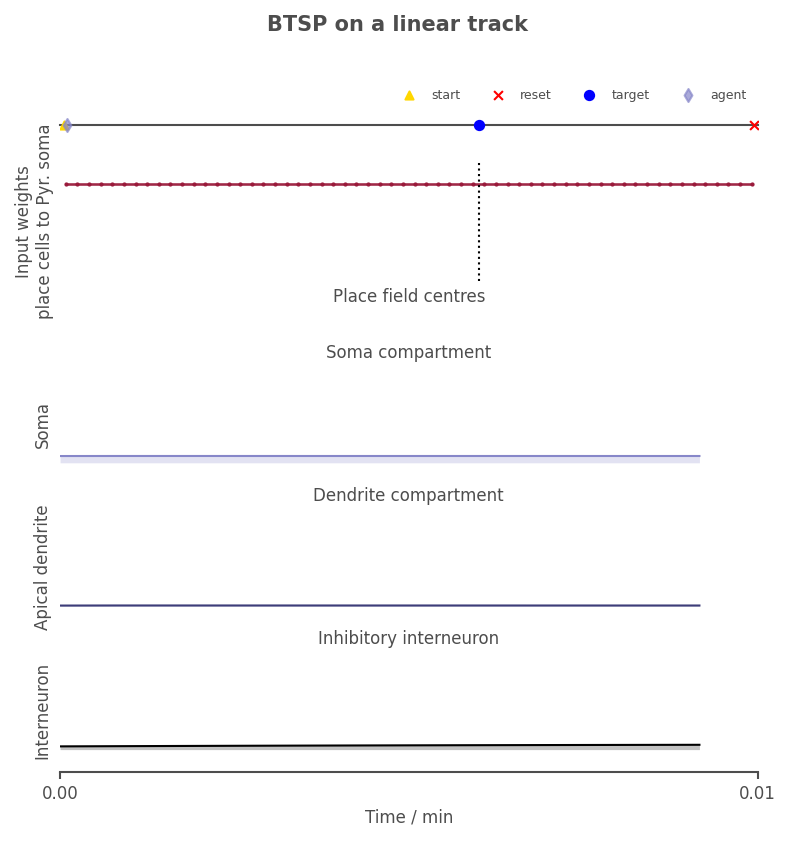

In [47]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=0, 
        t_end=None, 
        savename="5-full_timeseries",
        **all_animate_kwargs
        )
    anim